# Self-supervised learned representations - Lab

**Submission deadline:** Monday 10.01.2025

*Points:* There are 17+ points. **Aim to get 12 points (i.e. 12 points = maximum grade)**. The passing grade is 6 points.

## Submission instructions:

Submit your work through moodle before the deadline. For each task, make sure to have an implementation that fulfills the requirements and to answer the specified questions. Make sure to read the **_What do I expect for this task_** comments.

I provide some starter code, however, you are not required to use it as long as you properly solve the tasks. This means you can modify the code as you wish.

**Tips for a good submission**:

* Make sure you understand all the questions and answers. In case you don't understand something or you're not sure of your results/analyses, please reach out. I am always happy to help as best as I can. Even on your final submission is best to acknowledge when you are uncertain about something rather than coming up with made up explanations. I penalize being confidently wrong, but I'm totally ok with you having questions.
* Make sure that your notebook contains results (before presentation do `Runtime -> Restart and run all`).
* Use visuals, like tables and figures, to present your results. This is specially important when it comes to comparing different setups. E.g. if there is an exercise about comparing the loss curves with different hyperparameters, showing each individual loss curve in a separate cell is a bad way of visualizing it. Or even worse, just printing the losses. Instead, plot all the loss curves in a single figure with different colors for each setup. For best practices, check how scientific papers present results.
* Do not be fooled by randomness. Most of the algorithms we use involve random steps (e.g. random initialization). When you compare individual experiments, any difference that you observe might be just the effect of randomness. In order to properly assess results in such cases, you must present and analyze a few independent experiments and their statistics (e.g. average, standard deviations). This might not be feasible when we have large experiments, but most of your assignments involve experiments that take only a few minutes to run.

**Reach out to me at santiago.cuervo@lis-lab.fr for any question or issue you might encounter.**

# About the lab:

You will notice that although our lecture was mostly focused on algorithms for self-supervised learning, in this practice we will not be doing any self-supervised training (except language modeling, which you already did with GPT in the last lab). This is because self-supervised training usually requires large models and large amounts of data. So, in order not to be limited by compute or to be waiting for hours just to see if your solution gives the expected output, we will focus on analyzing and using the representations learned by already trained self-supervised models. This is, as a matter of fact, what we most often do in practice: we take a self-supervised pre-trained model (termed backbone) and use it to extract representations that we use as input to a much simpler model to solve our problem of interest. Since self-supervised learning excels at mining useful information, the obtained representations are useful for many applications.

# Problem 1: Word embeddings [4p]

Natural language processing tasks with deep neural networks require continuous representations for text.
[Word embeddings](https://en.wikipedia.org/wiki/Word_embedding) are mappings from a discrete
space (characters, subwords, words, etc.) to real-valued vectors. Word embeddings are learned either as a by-product of training on other tasks (e.g., language modeling, neural machine translation), or with networks designed specifically for the word embedding task.

One of the most popular architectures for training word embeddings is called [Word2vec](https://arxiv.org/abs/1301.3781). It builds on the idea that semantics (meaning) of a word can be defined through the contexts in which the word appears in the sentence (notice that this is the core idea behind self-supervised learning by prediction).

Let $w_1, w_2,\ldots,w_N$ be an $N$-word sentence in a natural language.
We define a context of a word $w_l$ a list of $n$ preceeding and following words
$w_{l-n},\ldots,w_{l-1},w_{l+1},\dots,w_{l+n}$. In word2vec we project each word $w$ linearly to obtain a vector that is the word representation $z$. Then we can do two things:

1. Predict a word based on its context (_Continuous Bag of Words (CBOW)_): we set the word $w_l$ as target and use the sum of the vectors corresponding to the context as input: x = $\sum_{i \in \{-n, \ldots, -1, +1, \ldots, n\}} z_i$. Then we pass this input through a softmax layer and train the model to predict the target word using a cross-entropy loss.

2. Predict the context based on the word (_Skip-grams_): we use the vector $z_l$ representing the word $w_l$ as input and use it to create training samples in which the context words are the target: $(z_l, w_{l-n}),\ldots,(z_l, w_{l-1}),(z_l, w_{l+1}),\ldots,(z_l, w_{l+n})$. As before, we pass the inputs through a softmax layer to predict the target and train the model using a cross-entropy loss.

![image.png](https://drive.google.com/uc?id=150F7dnPS8rfr1n3CUYwxEJ4cSFdSlFJa)

For a great explanation with more details on word2vec I suggest reading [the illustrated word2vec](https://jalammar.github.io/illustrated-word2vec/).

The underlying assumption in word2vec is that similar words appear in similar contexts.
For instance, words *Poland* and *Monaco* are similar in a sense, that they are singular nouns
describing abstract concepts of existing, european countries.
We can convince ourselves by looking at excerpts from Wikipedia articles
on Poland and Monaco:

* Despite **Monaco's independence** and separate foreign policy
* aimed to preserve **Poland's independence** and the szlachta's

* **Monaco joined the** Council of Europe in 2004
* **Poland joined the** Schengen Area in 2007

* nearly one-fifth **of Poland's population** – half of them
* Christians comprise a total of 83.2% **of Monaco's population**.

### Tasks
You will use word vectors pre-computed on a large dataset.
1. **(1 pt)** It has been observed that word embeddings allow to perform semantic arithmetic where, for instance

    **king** - **man** + **woman** ~= **queen**

    This *analogy* task is often used as a quality measure of word embeddings and showcases the importance of representation learning: words get mapped to a high-dimensional real vector space where things such as distances and  angles between vectors represent meaningful relations between concepts. Afterwards, by performing vector operations on that space, our models are capable of "reasoning" about concepts.
    
    In this exercise you will load word embeddings and compute their analogy score on a dataset of analogous pairs, expressed as an accuracy of predicting a paired item (**queen** in the example above).

    __What I expect for this task__:
* Try to think about the implications of this method working. What does the fact that these operations are possible tell us?
    
2. **(1 pt)** Word embedding capture approximate semantics. Under an assumption that words of similar semantics
    exist in different languages, a mapping $W: \mathbb{R}^{100}\mapsto\mathbb{R}^{100}$ (our embeddings for this task are of dimension 100) might be constructed that
    translates word embeddings between languages. [It has been shown](https://arxiv.org/abs/1309.4168) that such ortonormal mappings allow to express
    approximate, bilingual dictionaries. In addition, non-linear mappings do not offer additional benefit.

    Given a simple English-French dictionary of word pairs
    find an orthonormal mapping $W$ between English and French word embeddings using Procrustes analysis (the name sounds scary, but this part is done for you).

    __What I expect for this task__:
* As before, try to think about the implications of this method working. What does the fact that a simple ortonormal mapping (a rotation) allows for translation tell us?

3. **(2 pt)** Word embeddings can often be nicely visualized.

    3.1 **(1 pt)** Make a 2-D `PCA` plot of word embeddings for countries and their capital cities. Connect each country with its capital city with a line segment. Can you see any regularities?
    
    3.2 **(1 pt)** Plot 400 roughly most frequent words' embeddings in 2-D with `PCA`. Skip stop words, punctuations, artifact words, etc. You can be imprecise and use heuristics (e.g., select words than are at lest 3 charactes long). Can you see any regularities? Another method of making meaningful visualizations is `t-SNE`. Make another 2-D visualization, this time using `t-SNE`. Visualizations with `t-SNE` are obtained with gradient descent. Try to tweak optimization parameters to get lower optimization error, than the one with default parameters. Can you see any regularities this time?

    __What I expect for these tasks (1.3.1 and 1.3.2)__:
* Just tell me if you see anything interesting in the resulting plot (you probably should), and your intuitions behind it.

In [ ]:
# Modules needed for this problem
import numpy as np
import collections
import pickle
from scipy.linalg import orthogonal_procrustes
import tabulate
import random
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import pprint
import sklearn.feature_extraction
from termcolor import colored
import codecs
import nltk
from tqdm.notebook import tqdm

We first download the data and models needed:

In [ ]:
# Please note that this code needs only to be run in a fresh runtime.
# However, it can be rerun afterwards too.
!pip install -q gdown httpimport

![ -e word2vec_en_fr.pkl ] || gdown 'https://drive.google.com/uc?id=1FQbC92B4uY4HJ2XUADhQuBC2bWL_-oN_' -O word2vec_en_fr.pkl
![ -e questions_words.txt ] || gdown 'https://drive.google.com/uc?id=1Ia64QKg6x-vmjwDbWWJ5qxRxamWU1sbz' -O questions_words.txt
![ -e dict_en_fr.pkl ] || gdown 'https://drive.google.com/uc?id=112NnNp_BTlb9y8baUhv8n-qX2cd8FT_t' -O dict_en_fr.pkl
![ -e countries_capitals ] || gdown 'https://drive.google.com/uc?id=1ZTCuBZBnWZvgtBH7InhHRSLXW_I6mlp3' -O countries_capitals

Downloading...
From (original): https://drive.google.com/uc?id=1FQbC92B4uY4HJ2XUADhQuBC2bWL_-oN_
From (redirected): https://drive.google.com/uc?id=1FQbC92B4uY4HJ2XUADhQuBC2bWL_-oN_&confirm=t&uuid=4baaee3b-ce0c-42d5-878b-bc0d1c88cbd1
To: /content/word2vec_en_fr.pkl
100% 2.92G/2.92G [00:42<00:00, 68.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Ia64QKg6x-vmjwDbWWJ5qxRxamWU1sbz
To: /content/questions_words.txt
100% 604k/604k [00:00<00:00, 103MB/s]
Downloading...
From: https://drive.google.com/uc?id=112NnNp_BTlb9y8baUhv8n-qX2cd8FT_t
To: /content/dict_en_fr.pkl
100% 18.4k/18.4k [00:00<00:00, 47.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1ZTCuBZBnWZvgtBH7InhHRSLXW_I6mlp3
To: /content/countries_capitals
100% 4.70k/4.70k [00:00<00:00, 11.3MB/s]


In [ ]:
# Word embeddings assign a vector to each word. To use them we need three things:
# 1. the embeddings themselves
# 2. a dictionary from words to their embedding ids
# 3. an inverse dictionary

Embedding = collections.namedtuple(
    'Embedding',
    ['vec', 'word2idx', 'idx2word'])

"""Load dicts with the embeddings and vocab"""
with open('word2vec_en_fr.pkl', 'rb') as pickle_file:
    loaded_dict = pickle.load(pickle_file)

def make_word2vec(lang_dict):
    vec = lang_dict["embeddings"]
    idx2word = lang_dict["vocab"]
    word2idx = {w:i for (i,w) in enumerate(idx2word)}
    return Embedding(vec, word2idx, idx2word)

word2vec_en = make_word2vec(loaded_dict["en"])
word2vec_fr = make_word2vec(loaded_dict["fr"])

def load_analogies():
    '''Load tuples of analogies, e.g., (man, woman, king, queen)'''
    questions_path = 'questions_words.txt'
    analogies = [l.strip().split() for l in open(questions_path, 'r') \
                 if not l.startswith(':')]
    return analogies

## Problem 1, Task 1: Analogies

In [ ]:
def eval_analogies(vecs, analogies):
    """
    Compute the accuracy on the analogy task.

    In the task, quadruples of words are given (q1, q2, r1, r2).
    The words q1 and q2 are bound by a relation. The words r1 and r2
    are bound by the same relation. The task is to predict r2 knowing words
    q1, q2, and r1.

    Example:
    Quadruple [King, Queen, Man, Woman] yields the question
    King is to Queen as Man is to ????

    Args:
        word_vecs: Embeddings tupes
        analogies: list of quadruples: (q1, q2, r1, r2)

    Returns:
        percentage of correct answers
    """
    indexes = [[vecs.word2idx.get(w, None) for w in tupl] \
                for tupl in analogies]
    indexes = [tupl for tupl in indexes \
               if all([v is not None for v in tupl])]
    # indexes holds quadruples of ints giving the ids of words from our vocab.
    indexes = np.asarray(indexes)
    print('Got vocab for %d/%d pairs' % (indexes.shape[0], len(analogies)))

    # Extract the vectors for the query words
    q1 = vecs.vec[indexes[:, 0]]
    q2 = vecs.vec[indexes[:, 1]]
    r1 = vecs.vec[indexes[:, 2]]

    # Extractr the word IDs for the correct answers
    r2_inds = indexes[:, 3]

    #
    # TODO
    #
    # Compute the approximate location of word r2 as r2 = r1 + (q2 - q1)
    # Find the word closest to this location using cosine distance.
    # Return it's id and compute the accurracy.
    #

    r2_pred = r1 + (q2 - q1)

    # Normalize length and compute dot product between r2_pred and word_vecs
    # to get cosine distance
    r2_pred_norm = r2_pred / np.linalg.norm(r2_pred, axis=1, keepdims=True)
    vecs_norm = vecs.vec / np.linalg.norm(vecs.vec, axis=1, keepdims=True)

    # Compute in chunks to save memory
    r2_pred_inds = np.concatenate([np.argmax(r2_pred_norm[i:i+1000].dot(vecs_norm.T), axis=1) \
                                   for i in range(0, r2_pred.shape[0], 1000)])
    return 100.0 * (r2_pred_inds == r2_inds).sum() / r2_inds.shape[0]

**COMMENT :** **Implications of this method working**

The fact that semantic arithmetic works in word embeddings implies that word relationships are stored in a structured way within a high-dimensional space rather than just memorizing word meanings in isolation. Meaning and relationships between words are embedded  geometrically, this is why we can apply geometric like operations.

The difference **(q2 - q1)** captures a directional vector in the embedding space that encodes the relationship between the first word pair.

Adding this directional vector to another word **(r1 + (q2 - q1))** applies the same semantic transformation, ideally leading to the correct analogous word.

In [ ]:
# Load analogy tuples, e.g., (man, woman, king, queen)
analogies = load_analogies()

# Some are uppercased geographical names
analogies_lower = [[w.lower() for w in tupl] for tupl in analogies]

print(analogies[0])

['Athens', 'Greece', 'Baghdad', 'Iraq']


In [ ]:
print('\nWord2vec analogy task accuracy:')
print('-------------------------------')
# Word2vec has case information
print(eval_analogies(word2vec_en, analogies), '% correct')


Word2vec analogy task accuracy:
-------------------------------
Got vocab for 9378/19544 pairs
20.814672638089146 % correct


**COMMENT :** **Implications of this accuracy result**

The 20.8% accuracy is reasonable because:

Many words have multiple synonyms (e.g., "woman" vs. "lady"), and embeddings may pick a valid synonym that doesn't exactly match the dataset labels.
Word embeddings are trained on large amount of texts, where relationships can be influenced by context and frequency, leading to variability in predictions.

Case sensitivity and vocabulary mismatches can reduce accuracy.

## Problem 1, Task 2: Translation through alignment of embedding spaces

In [ ]:
# Load a simple dict of English, French word pairs
with open('dict_en_fr.pkl', 'rb') as pickle_file:
    en_fr = pickle.load(pickle_file)
# Keep those, for which we have embeddings
en_fr = {en:fr for (en,fr) in en_fr.items() \
         if en in word2vec_en.word2idx and fr in word2vec_fr.word2idx}
print('Dictionary size:', len(en_fr))
print('good --', en_fr['good'])

Dictionary size: 908
good -- bien


In [ ]:
# Select word embeddings for dictionary words
en_words = sorted(en_fr.keys())
V_en = word2vec_en.vec[[word2vec_en.word2idx[w] for w in en_words]]
V_fr = word2vec_fr.vec[[word2vec_fr.word2idx[en_fr[w]] for w in en_words]]
print(V_en.shape, V_fr.shape)

(908, 100) (908, 100)


In [ ]:
# Find an orthogonal transformation from V_en to V_fr.
# which minimizes square reconstruction error
W = orthogonal_procrustes(V_en, V_fr)[0]

In [ ]:
def translate(W, v, vecs2):
    #
    # TODO
    #
    # Transform source word vector v using W getting a location in target space.
    # Find the closest word in target space using the cosine distance.
    #
    vTransformed = v.dot(W)

     # Normalize the transformed vector and target embeddings
    vTransformed_norm = vTransformed / np.linalg.norm(vTransformed)/ np.sqrt(np.sum(vTransformed ** 2))
    vecs_norm = vecs2.vec / np.sqrt(np.sum(vecs2.vec ** 2, axis=1, keepdims=True))
    # Compute in chunks to save memory
    idx = np.argmax(vTransformed.dot(vecs_norm.T))
    return vecs2.idx2word[idx]

# Select random, fairly frequent words not from the dictionary
tr_words = [i for i in np.random.randint(1000, 2000, 100) \
            if word2vec_en.idx2word[i] not in en_fr]
tr_words = tr_words[:20]

rows = [[word2vec_en.idx2word[i], translate(W, word2vec_en.vec[i], word2vec_fr)] \
         for i in tr_words]
print(tabulate.tabulate(rows))

------------  ----------
net           milliard
iphone        iphone
directed      coproduit
affairs       secrétaire
pain          douleur
topics        thèmes
driving       conduite
nation        nation
secret        secret
older         âge
watching      regarder
democratic    démocrate
numerous      nombreux
mail          courrier
pa            nj
flag          drapeau
pack          pack
el            el
inch          épaisseur
pennsylvania  ohio
------------  ----------


**COMMENT :** **Implications of this method working**

This method working implies that word meanings are captured across languages in a similar geometric structure within the high-dimensional embedding space.

The fact that a simple orthonormal transformation (a rotation) is sufficient to map between English and French embeddings means that the semantic relationships between words are largely language-independent.

It also means that translation can be approximated as a direct alignment of these structures.

**COMMENT ON RESULT:**

Some of the translated french word were not exactly same as when I used google translate (e.g: **"perhaps"** translate to **"certainement"** instead of **"peut-être"**), maybe these translations are related to contextual meanings.



## Problem 1, Task 3: Visualizing the embedding space

### Task 3.1 : Finding geometric regularities

In [ ]:
capitals = [l.strip().split('\t') for l in codecs.open('countries_capitals', 'r', 'utf-8')]
capitals = {country.lower():capital.lower() for (country,capital) in capitals}

# Select those present in Word2vec vocab
capitals = {k:v for (k,v) in capitals.items() \
            if k in word2vec_en.word2idx and v in word2vec_en.word2idx}

# Flatten the array to have a list of [country, capital, country, capital, ...]
geo = [e for pair in capitals.items() for e in pair]
print(len(geo) // 2, 'pairs', geo[:6])

127 pairs ['afghanistan', 'kabul', 'albania', 'tirana', 'algeria', 'algiers']


In [ ]:
geo_inds = [word2vec_en.word2idx[w] for w in geo]
geo_vecs = word2vec_en.vec[geo_inds]
print(geo_vecs.shape)

(254, 100)


In [ ]:
#
# TODO
# use PCA from sklearn.decomposition to project the countries and capitals into 2D.
# draw lines connecting each country with its capital
#
# Hint:
# - the function "annotate" can be used to put text onto the plot
#

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Use PCA to project the country and capital vectors into 2D
pca = PCA(n_components=2)
geo_2d = pca.fit_transform(geo_vecs)

# Print the shape of the projected data
print(geo_2d.shape)

(254, 2)


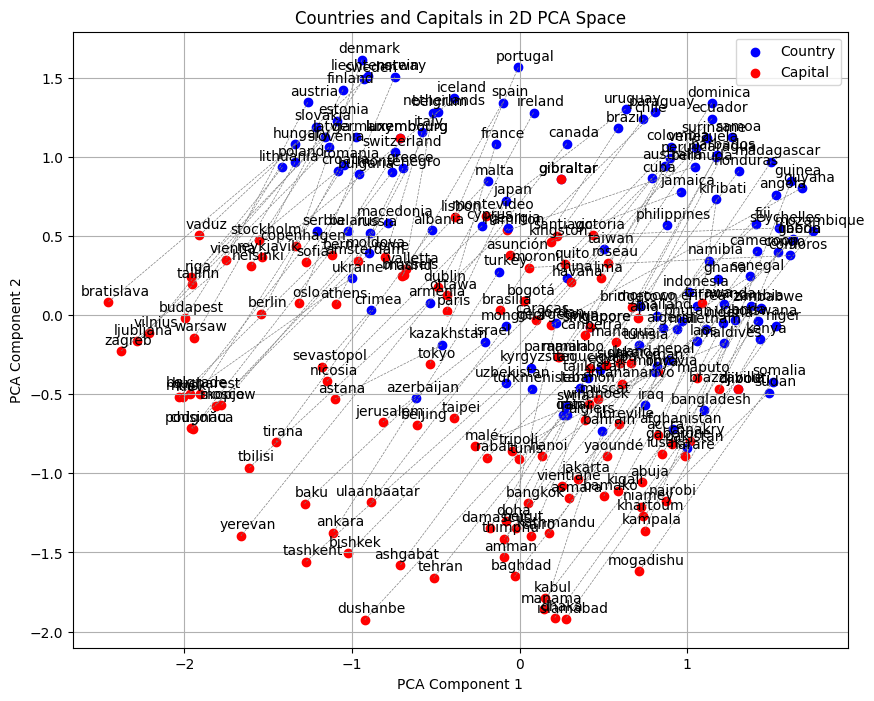

In [ ]:
# Plot the countries and capitals
plt.figure(figsize=(10, 8))
for i in range(0, len(geo_2d), 2):
    country = geo[i]
    capital = geo[i + 1]
    x1, y1 = geo_2d[i]  # Country coordinates
    x2, y2 = geo_2d[i + 1]  # Capital coordinates

    # Plot the country and capital points
    plt.scatter(x1, y1, color='blue', label='Country' if i == 0 else "")
    plt.scatter(x2, y2, color='red', label='Capital' if i == 0 else "")

    # Draw a line connecting the country to its capital
    plt.plot([x1, x2], [y1, y2], color='gray', linestyle='--', linewidth=0.5)

    # Annotate the country and capital points
    plt.annotate(country, (x1, y1), textcoords="offset points", xytext=(5, 5), ha='center')
    plt.annotate(capital, (x2, y2), textcoords="offset points", xytext=(5, 5), ha='center')

# Add labels and legend
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Countries and Capitals in 2D PCA Space')
plt.legend()
plt.grid(True)
plt.show()

**COMMENT ON RESULTING PLOT**

Countries and their capitals are generally close together meaning that that the relationship between countries and capitals is captured meaningfully in the word embedding space.


1. Nearby Countries Likely Have Similar     
    Embeddings:

    Countries from the same region (e.g., European countries) appear closer to each other, maybe because they frequently co-occur in text and share geopolitical, economic, and cultural contexts.

    This similarity causes their PCA projections to cluster in certain regions of the 2D space.


2.  Line Orientation Reflects Regional
    Structure:

    Several Europe-based country-capital pairs have similar slanting directions, and this suggest that PCA preserves their relative semantic positioning.
    Similarly, African or Asian countries show a different predominant slant, indicating that their embeddings capture a distinct textual context in large amount of text.

3. PCA Compression Can Distort Absolute   
    Directions:

    While PCA reduces high-dimensional data, it tries to retain key relationships. The consistent slant of lines within a cluster suggests that PCA preserved some aspect of their spatial relationships from the original word embedding space.


### Task 3.2 Visualizing meaningful clusters

In [ ]:
# Select words starting from the 200th to ommit stop words,
# which have at least 3 chars
top_words = [w for (i,w) in enumerate(word2vec_en.idx2word) \
             if i > 200 and len(w) >= 3][:400]
top_inds = [word2vec_en.word2idx[w] for w in top_words]
#
# TODO: make a 2D PCA projection of the selected words.
#
# Extract the word vectors for the selected words
top_vecs = word2vec_en.vec[top_inds]

# Use PCA to project the word vectors into 2D
pca = PCA(n_components=2)
top_2d = pca.fit_transform(top_vecs)

# Print the shape of the projected data
print(top_2d.shape)

(400, 2)


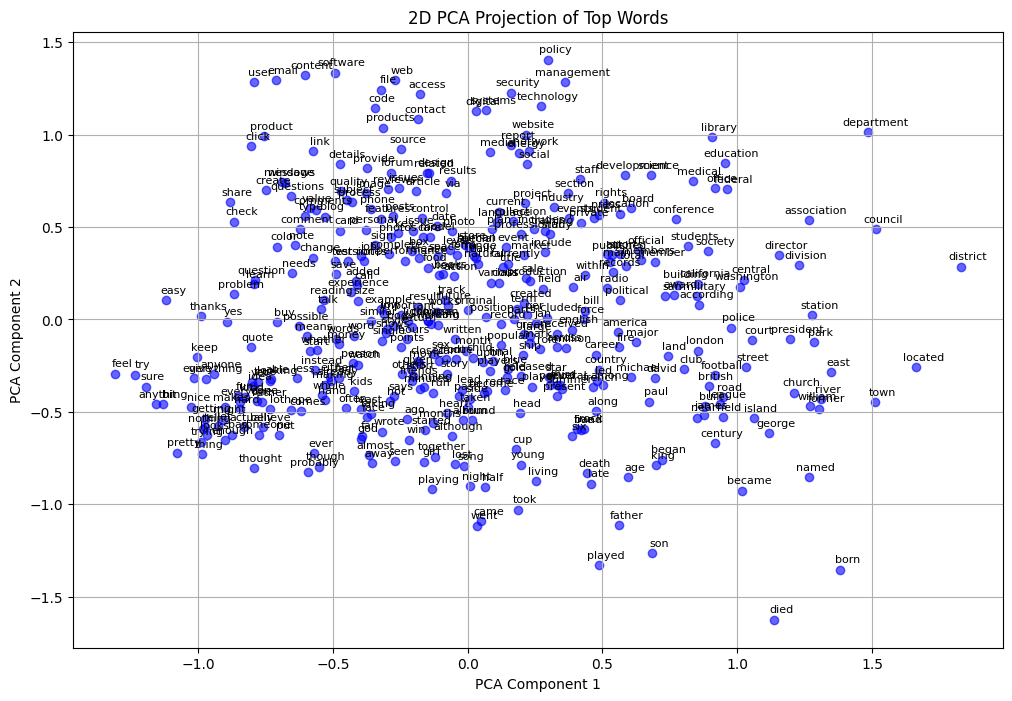

In [ ]:
# Plot the words in 2D PCA space
plt.figure(figsize=(12, 8))
plt.scatter(top_2d[:, 0], top_2d[:, 1], color='blue', alpha=0.6)

# Annotate each point with its corresponding word
for i, word in enumerate(top_words):
    plt.annotate(word, (top_2d[i, 0], top_2d[i, 1]), textcoords="offset points", xytext=(5, 5), ha='center', fontsize=8)

# Add labels and title
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('2D PCA Projection of Top Words')
plt.grid(True)
plt.show()

**COMMENT ON RESULTING PLOT**

1. Semantic Clustering

    Words with similar meanings or contexts tend to cluster together. For example, words related to politics ("policy," "government," "political") are close by in the same region.

2.  Functional Grouping

    Words related to education (e.g. "library," "education," "department") form another grouping. In the same way, words about time or history (e.g., "century," "born," "died") appear together.

3.  Gradient of Abstraction

    Some clusters have abstract terms (e.g., "policy," "management") positioned differently from concrete words (e.g., "father," "building").

In [ ]:
#
# TODO: make a 2D t-SNE projection of the selected words.
# Things will cluster much nicer
#
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Extract the word vectors for the selected words
top_vecs = word2vec_en.vec[top_inds]

# Use t-SNE to project the word vectors into 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
top_2d_tsne = tsne.fit_transform(top_vecs)

# Print the shape of the projected data
print(top_2d_tsne.shape)

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


(400, 2)


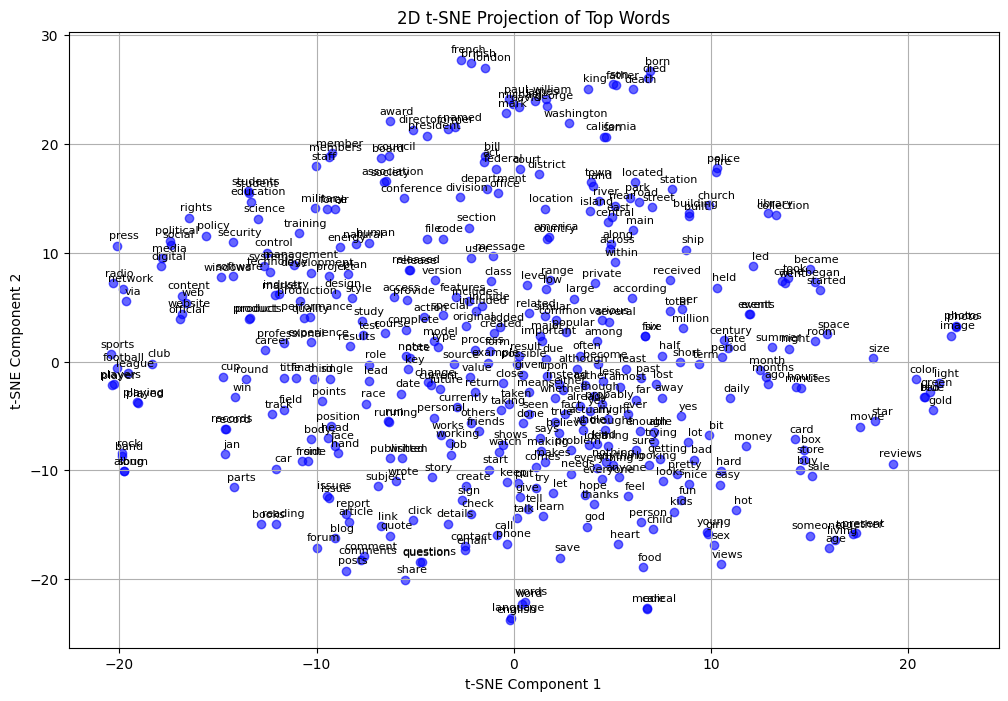

In [ ]:
# TODO: plot and zomm in on 3 meaningful clusters
# Plot the words in 2D t-SNE space
plt.figure(figsize=(12, 8))
plt.scatter(top_2d_tsne[:, 0], top_2d_tsne[:, 1], color='blue', alpha=0.6)

# Annotate each point with its corresponding word
for i, word in enumerate(top_words):
    plt.annotate(word, (top_2d_tsne[i, 0], top_2d_tsne[i, 1]), textcoords="offset points", xytext=(5, 5), ha='center', fontsize=8)

# Add labels and title
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('2D t-SNE Projection of Top Words')
plt.grid(True)
plt.show()

**COMMENT ON RESULTING PLOT**

t-SNE visualization shows better clustering than PCA:

Words with similar meanings are grouped more tightly compared to PCA.
For example, geographical terms (e.g., "california," and "washington") appear together. Also terms ("became," "began," "starte") appear together


There seem to be distinct clusters of words related to different topics.
For example, words about the body (e.g., "head," "face," "hand") are in one area, while publication terms (e.g., "report," "article," "issues") are in another.

# Problem 2: Sentence embeddings [8p+]

In this exercise you will build a simple chatbot that uses neural representations of words and sentences to perform a nearest neighbor selection of responses.

We have two sets of data:
- `./reddit_pairs.txt` of excerpts of [Reddit](https://www.reddit.com/) conversations,
- `./hackernews_pairs.txt` of excerpts from [Hackernews](https://news.ycombinator.com/).

The two corpuses are formatted as `tab`-separated pairs of utterances: a `prompt` and a `response`. Successive lines belong to different conversations.

The main idea of the chatbot is to build a representation of the user `input` and of all `prompts` from the corpus. Then select the best (or randomly one of the top few) matches and print the associated `response`.

The key to get the bot working is to create good sentence representations. We will try:
- Averaging word2vec embeddings. From the task on word analogies in Problem 1 we saw that arithmetics of word embeddings are associated with meaning, so averaging often yields reasonable sentence representations.
- Using sentence models such as [BERT (Bidirectional Encoder Representations from Transformers)](https://aclanthology.org/N19-1423.pdf).

BERT is a model to learn sentence representations with a very similar working principle as skipgrams in word2vec: it learns to predict a word based on the context in which it occurs. The main difference is that instead of representing the context as sums of individual word vectors, it computes it using transformers. Here is how it works:

![image.png](https://drive.google.com/uc?id=1jom3pNdKx7kLgwWHbbXhahm8em6x8JNf)

1. We take a sentence and mask some of its tokens with a special token `[MSK]`. We also prepend the sentence with a special token `[CLS]`.
2. We represent every token in the sentence (includding the `[MSK]` and `[CLS]` tokens) with a different vector. These vectors are randomly initialized and learned throughout training.
3. We pass the sequence of vectors through a transformer.
4. We use the output of the transformer in the masked tokens to predict the original value of the token (pre-masking) using a softmax layer and  a cross-entropy loss. Since the output of the transformer at each position contains information from all the other tokens in the sentence due to self-attention, this means we are predicting the masked word based on its context.

Since the `[CLS]` token is independent of the input and never masked, the model tends to pack information from the whole sentence into it. Therefore, after training we can use the output of the transformer in the position of the `[CLS]` token (first) as a representation of the whole sentence. Alternatively, we can average the transformer outputs across the sequence axis.   

#### Warning:
The Reddit corpus may contain abusive language, it was not heavily cleaned.

### Tasks

The code below is a starting point, but you can develop you own. The following list suggests some actions to try, along with the points that reflect the estimated difficulty. The first 4 tasks are required, the rest are optional.

1. **(1 pt)** Implement the `getResponse` function of `KNNChatbot` to return responses using k-nearest neighbor matches.
2. **(2 pt)** Represent sentences by averaging their word vectors. Properly handle tokenization (you can use regular expressions or e.g. `nltk` library). Describe how you handle lower and upper cased words. Try a few nearest neighbor selection methods (such as euclidean or cosine distance). See how embedding normalization affects the results (you can normalize individual word vectors, full sentence vectors etc.).

    __What I expect for this task__:
    * Compare the quality of the chats relative to the already implemented `OneHotEncoder`. Does it work better? Why?

3. **(2 pt)** Use the [transformers](https://huggingface.co/transformers) 🤗 package to load a pretrained BERT model. Use it to represent sentences.

    _**IMPORTANT: encoding the whole corpus using BERT can take a while. Implementing batched encoding is advised. To avoid re-computing, make sure to save the BERT encoded corpus to disk once you have computed it. You can use**_ `np.save` **_and_** `np.load`**.**

    __What I expect for this task__:
    * Compare the quality of the chats relative to using the word2vec sentence representations. Does it work better? Why?

4. **(1 pt)** Incoportate context: keep a running average of past conversation turns.

    __What I expect for this task__:
    * Show me that now answers are dependent of context. Try to come up with some examples in which having context can help.
5. **(1 pt)** Do data cleaning (including profanieties), finding rules for good responses.

    __What I expect for this task__:
    * This is a representation-based lab. Make sure to use a criterion based on representations to do your data cleaning. _Hint: can distances to profanity embeddings somehow help you?_
6. **(1 pt+)** Implement your own enhancements.

Let's download the data needed:

In [ ]:
# Download conversation corpuses
![ -e  hackernews_pairs.txt ] || gdown 'https://drive.google.com/uc?id=1B8APZpI03gOdv8L537i27VP2zuOIW8z-' -O hackernews_pairs.txt
![ -e  reddit_pairs.txt ] || gdown 'https://drive.google.com/uc?id=1Gjof-ECoK6VJ1r5BFfQUDnCIne7o8nXO' -O reddit_pairs.txt

Downloading...
From: https://drive.google.com/uc?id=1B8APZpI03gOdv8L537i27VP2zuOIW8z-
To: /content/hackernews_pairs.txt
100% 4.39M/4.39M [00:00<00:00, 169MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Gjof-ECoK6VJ1r5BFfQUDnCIne7o8nXO
To: /content/reddit_pairs.txt
100% 3.89M/3.89M [00:00<00:00, 120MB/s]


In [ ]:
# We load the data
prompts = []
responses = []
err_lines = []
with open('./reddit_pairs.txt') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        line = line.split('\t')
        if len(line)!=2:
            err_lines.append(line)
        else:
            prompts.append(line[0])
            responses.append(line[1])

with open('./hackernews_pairs.txt') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        line = line.split('\t')
        if len(line)!=2:
            err_lines.append(line)
        else:
            prompts.append(line[0])
            responses.append(line[1])

print(f"Failed to parse the following {len(err_lines)} lines: {err_lines}")
print(f"Sample dialogue pairs: \n{pprint.pformat(list(zip(prompts[:15], responses)))}")

Failed to parse the following 7 lines: [['1602 link karma', '11259 comment karma', 'damn you got almost all your karma here'], ['lol'], ['50$ skin pls'], ['omg his posting how'], ['11', 'inches to be precise :)', 'holy shit your girl has found herself a fuckin unicorn!'], ['( ) no fuk'], ['looks like you post on multiple porn subreddits']]
Sample dialogue pairs: 
[('show', 'me your moves?'),
 ('haters gonna hate', 'hate'),
 ('i think he is doing sarcasm.',
  'hahaha, you stupid twat, go and have a wank'),
 ('i can do 38 for void head :)', '39k man cant go for 38k'),
 ('brb getting hit by a car', 'did your mate, also buy you a computer?'),
 ('reason ?', 'to pay for bandwidth to troll people online.'),
 ('*155k notes...*', 'welcome to tumblr'),
 ('is it just me or is this pitched up?',
  'might be to avoid copyright issues.'),
 ('no chapter this week bud :(', '**cough*'),
 ("that's gonna come back for a block in the back",
  "but it doesn't matter. fuck this game. connor cook playing ful

In [ ]:
# Just a template for our encoders
class BasicEncoder:
    def encode(self, sentence):
        # this is a base class!
        raise NotImplementedError

    def encode_corpus(self, sentences):
        ret = [self.encode(sentence) for sentence in tqdm(sentences)]
        return np.vstack(ret)

We start with the simplest possible sentence encoder. We use a [count vectorizer](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html), which represents a sentence as a vector of the dimension of our vocabulary in which the number at the index $i$ is the number of times that the $i$-th word of our vocabulary occurs in the sentence. E.g. for a vocabulary of size 10, the sentence: *"to be or not to be"*, and the indices of the words: {"to": 3, "be": 0, "or": 6, "not": 9}, then our sentence representation would be $[2,0,0,2,0,0,1,0,0,1]$. This is not really a good strategy, as the location in representation space of the sentence embeddings has no relation to its meaning, but it will give us a baseline over which we should see improvements when using better sentence embedding methods.

In [ ]:
# The simplest possible encoder, we represent words as one-hot vectors using the
class OneHotEncoder(BasicEncoder):
    def __init__(self, sentences):
        self.vectorizer = sklearn.feature_extraction.text.CountVectorizer()
        self.vectorizer.fit(sentences)

    def encode(self, sentence):
        return self.vectorizer.transform([sentence])[0]

    def encode_corpus(self, sentences):
        # Override because sklearn already works on batches
        encodings = self.vectorizer.transform(sentences)
        # Note: this code needs to handl the scipy sparse matrix
        # which has subtle differences with numpy ndarrays
        norms = np.array((encodings.power(2)).sum(1))**0.5
        encodings = encodings.multiply(1.0 / norms)
        return encodings

countEncoder = OneHotEncoder(prompts)
encodings = countEncoder.encode_corpus(prompts)

prompt = "Ultimate question: Windows or Linux?"
enc = countEncoder.encode(prompt)

# Deal with encodings being sparse matrices. Word2vecs will not have these pecularities
scores = (encodings @ enc.T).toarray().ravel()
top_idx = scores.argsort()[-10:][::-1]

for idx in top_idx:
    print(scores[idx], prompts[idx], ':', responses[idx])

1.0606601717798212 is in windows or in linux? : windows
1.0 1 or 2? : * or 3
1.0 p or i : yes
1.0 1 or 2? : 2 in the car this morning for me
1.0 3 or 4 : ok...
1.0 Windows? : Unix based systems
1.0 or : god damnit stop teasing me
1.0 Question. : In a sense 'maybe not'.
1.0 Question. : This is a good question!
1.0 or : ty m8


<ipython-input-5-505d357f77e3>:16: RuntimeWarning: divide by zero encountered in divide
  encodings = encodings.multiply(1.0 / norms)


## Problem 2, Task 1: Implement the KNN chatbot

In [ ]:
# TODO: build a simple dialogue system using these k-nearest neighbor matches
# perform a few test conversations
import numpy as np
import random
from sklearn.metrics.pairwise import cosine_similarity

class KNNChatbot:
    def __init__(self, encoder, corpus, k=1):
        self._encoder = encoder
        self._sentenceEmbeddings = corpus[0]
        self._responses = corpus[1]
        self.k = k

    def getResponse(self, query, epsilon=0.0):
        query = self._encoder.encode(query)

                # Compute cosine similarity scores
        if hasattr(self._sentenceEmbeddings, "toarray"):  # Handle sparse matrices
            scores = self._sentenceEmbeddings.dot(query.T).toarray().ravel()
        else:  # Handle dense arrays
            scores = cosine_similarity([query], self._sentenceEmbeddings)[0]

        topIdxs = np.argsort(scores)[-self.k:][::-1]   # Compute top-k neighbors
        if random.random() < epsilon: # With probability epsilon return the response of one of the top-k neighbors
            return self._responses[np.random.choice(topIdxs)]
        else: # With probability 1 - epsilon just return the response of the nearest neighbor
            return self._responses[topIdxs[0]]

In [ ]:
chatBot = KNNChatbot(countEncoder, (encodings, responses))

print(colored('Hal2021:\n', 'red'), "Good morning, Dave.")

while True:
    try:
        print(colored('Me: ', 'blue'))
        prompt = input()
        print(colored('Hal2021:\n', 'red'), chatBot.getResponse(prompt, epsilon=0.0))
        if prompt.lower() == 'bye':
            break
    except KeyboardInterrupt:
        break

Hal2021:
 Good morning, Dave.
Me: 
good morning
Hal2021:
 lie.
Me: 
why, is your morning not good?
Hal2021:
 because he knows the answer?
Me: 
what?
Hal2021:
 ya heard fam
Me: 
lolx
Hal2021:
 Ah, you're right.
Me: 
bye
Hal2021:
 bye, won't miss u:^(


**COMMENT ON COMPARISON BETWEEN ONEHOTENCODER AND KNN CHAT BOTS**

1. Semantic Understanding

    **OneHotEncoder:** Relies on exact word matches. It doesn't capture word relationships, leading to random or nonsensical responses.
    Example: "1 or 2?" → " or 3"* (irrelevant response)
    Example: "Windows?" → "Unix-based systems" (slightly better match but lacks reasoning)

    **KNNChatbot:** Uses word embeddings, which capture word relationships. However, the chatbot still struggles with coherence.
    Example: "Good morning" → "lie." (incorrect but at least related to truth/falsity)
    Example: "Why, is your morning not good?" → "because he knows the answer?" (confused but somewhat engaging)
2. Conversational
    **OneHotEncoder:** Disjointed, non-sequential responses due to reliance on token matching rather than meaning.
    **KNNChatbot:** Shows some conversational continuity, but still produces random or out-of-context answers. It recognizes conversational context better but doesn’t maintain a logical thread.
3. Meaningful Response
    **OneHotEncoder:** Many responses are either irrelevant or placeholders like "ty m8", "god damnit stop teasing me".
    **KNNChatbot:** Responses contain some conversational logic ("Ah, you're right." in response to "lolx"), but randomness still affects coherence.
4. Edge Cases & Errors
    **OneHotEncoder:** Generates completely off-topic answers when words don’t match exactly.
    **KNNChatbot:** Shows ambiguity when unable to find a strong match ("why, is your morning not good?" → "because he knows the answer?"). It tries but fails to stay on-topic.

**COMMENT ON BETTER CHAT AND WHY**

KNN CHATBOT performs better.

KNNChatbot provides more contextually relevant responses than OneHotEncoder because it recognizes word relationships, unlike OneHotEncoder, which only counts word occurrences.

## Problem 2, Task 2: Sentence representations as average of word embeddings

**NORMALIZING SENTENCE**

In [40]:
import numpy as np
import nltk

class Word2VecEncoder(BasicEncoder):
    def __init__(self, vecs):
        self._vecs = vecs
        self._tokenizer = nltk.tokenize.RegexpTokenizer(r'\w+')
        self._embeddingDim = 100

    def _get_vec(self, word):
        # TODO:
        # Find the vector for word, or use a suitable out-of-vocabulary vector
        if word in self._vecs.word2idx:
            return self._vecs.vec[self._vecs.word2idx[word]]
        else:
            return np.zeros(self._embeddingDim)           # Return zero vector for OOV words

    def encode(self, sentence, normalizeByWord=True):
        ret = np.zeros(self._vecs.vec.shape[1])
        for token in self._tokenizer.tokenize(sentence):
             # Handle lowercasing here
            token = token.lower()
            word_vec = self._get_vec(token)
            ret += word_vec
        ret /= (np.linalg.norm(ret) + 1e-5)
        return ret

word2vecEncoder = Word2VecEncoder(word2vec_en)
encodings = word2vecEncoder.encode_corpus(prompts)

  0%|          | 0/125497 [00:00<?, ?it/s]

**COSINE SIMILARITY**

In [41]:
prompt = "Ultimate question: Windows or Linux?"
enc = word2vecEncoder.encode(prompt)
scores = encodings @ enc.T
top_idx = scores.argsort()[-10:][::-1]

for idx in top_idx:
    print(scores[idx], prompts[idx], ':', responses[idx])

0.9109017860787854 is in windows or in linux? : windows
0.8989687923184642 I know ubuntu, osx and windows 7 phone home for certains scenarios. : It's possible to disable tracking on all of those though.
0.8710982359219961 Would you rather work on the linux kernel instead of windows? : What's the relation to the post to which you're replying?
0.8636849576424768 Some window managers on linux describe this as "sticky windows". : OK, I get it.
0.8636849576424768 Some window managers on linux describe this as "sticky windows". : I don't know win 10, I use xmonad.
0.8620690202445048 It's not that simple to just upgrade from windows 7. : What about running them in virtual machine?
0.8619266451506478 the out of the box linux compatibility is a game of chance on those. : I used a laptop with a broadcom card 2-3 years ago; it worked for me.
0.8609433963099871 my boss uses windows xp. : it's a lot better than vista :)
0.8595314283161434 linux. : linux indeed.
0.8595314283161434 Linux? : Unfortuna

**EUCLIDEAN DISTANCE**

In [42]:
prompt = "Ultimate question: Windows or Linux?"
enc = word2vecEncoder.encode(prompt)
scores = np.linalg.norm(encodings - enc, axis=1)
top_idx = np.argsort(scores)[:10]

for idx in top_idx:
    print(scores[idx], prompts[idx], ':', responses[idx])

0.42212757867908685 is in windows or in linux? : windows
0.4495100327414986 I know ubuntu, osx and windows 7 phone home for certains scenarios. : It's possible to disable tracking on all of those though.
0.5077403327376276 Would you rather work on the linux kernel instead of windows? : What's the relation to the post to which you're replying?
0.5221366036218856 Some window managers on linux describe this as "sticky windows". : I don't know win 10, I use xmonad.
0.5221366036218856 Some window managers on linux describe this as "sticky windows". : OK, I get it.
0.5252212543095255 It's not that simple to just upgrade from windows 7. : What about running them in virtual machine?
0.5254930034378046 the out of the box linux compatibility is a game of chance on those. : I used a laptop with a broadcom card 2-3 years ago; it worked for me.
0.5273605438840585 my boss uses windows xp. : it's a lot better than vista :)
0.530028474089619 Linux? : Unfortunately not.
0.530028474089619 linux. : linux

**NORMALIZING INDIVIDUAL WORDS**

In [43]:
import numpy as np
import nltk

class Word2VecEncoder(BasicEncoder):
    def __init__(self, vecs):
        self._vecs = vecs
        self._tokenizer = nltk.tokenize.RegexpTokenizer(r'\w+')
        self._embeddingDim = 100

    def _get_vec(self, word):
        # TODO:
        # Find the vector for word, or use a suitable out-of-vocabulary vector
        if word in self._vecs.word2idx:
            return self._vecs.vec[self._vecs.word2idx[word]]
        else:
            return np.zeros(self._embeddingDim)           # Return zero vector for OOV words

    def encode(self, sentence, normalizeByWord=True):
        ret = np.zeros(self._vecs.vec.shape[1])
        for token in self._tokenizer.tokenize(sentence):
             # Handle lowercasing here
            token = token.lower()
            word_vec = self._get_vec(token)
            word_vec = word_vec / np.linalg.norm(word_vec) if np.linalg.norm(word_vec) > 0 else word_vec
            ret += word_vec
        ret /= (np.linalg.norm(ret) + 1e-5)
        return ret

word2vecEncoder = Word2VecEncoder(word2vec_en)
encodings = word2vecEncoder.encode_corpus(prompts)

  0%|          | 0/125497 [00:00<?, ?it/s]

**COSINE SIMILARITY**

In [44]:
prompt = "Ultimate question: Windows or Linux?"
enc = word2vecEncoder.encode(prompt)
scores = encodings @ enc.T
top_idx = scores.argsort()[-10:][::-1]

for idx in top_idx:
    print(scores[idx], prompts[idx], ':', responses[idx])

0.8669429601605861 I know ubuntu, osx and windows 7 phone home for certains scenarios. : It's possible to disable tracking on all of those though.
0.8659954793796191 is in windows or in linux? : windows
0.8388735510657362 It's not that simple to just upgrade from windows 7. : What about running them in virtual machine?
0.836634637038869 OS X server mail setup is easy. : Yes---you're absolutely right.
0.8319621823833875 the out of the box linux compatibility is a game of chance on those. : I used a laptop with a broadcom card 2-3 years ago; it worked for me.
0.8311807262086399 Are you rebooting all your windows servers for each little update too then? : No.
0.8307192312161333 latest security pack for xp is actually 3 : *service pack
0.8268114734577294 Some window managers on linux describe this as "sticky windows". : I don't know win 10, I use xmonad.
0.8268114734577294 Some window managers on linux describe this as "sticky windows". : OK, I get it.
0.826195036969077 I have had really g

**EUCLIDEAN DISTANCE**

In [45]:
prompt = "Ultimate question: Windows or Linux?"
enc = word2vecEncoder.encode(prompt)
scores = np.linalg.norm(encodings - enc, axis=1)
top_idx = np.argsort(scores)[:10]

for idx in top_idx:
    print(scores[idx], prompts[idx], ':', responses[idx])

0.5158518005240339 I know ubuntu, osx and windows 7 phone home for certains scenarios. : It's possible to disable tracking on all of those though.
0.5176789211741855 is in windows or in linux? : windows
0.567659848806026 It's not that simple to just upgrade from windows 7. : What about running them in virtual machine?
0.5715935126810551 OS X server mail setup is easy. : Yes---you're absolutely right.
0.5797094402776923 the out of the box linux compatibility is a game of chance on those. : I used a laptop with a broadcom card 2-3 years ago; it worked for me.
0.5810561380631591 Are you rebooting all your windows servers for each little update too then? : No.
0.5818494501682787 latest security pack for xp is actually 3 : *service pack
0.5885279773638822 Some window managers on linux describe this as "sticky windows". : I don't know win 10, I use xmonad.
0.5885279773638822 Some window managers on linux describe this as "sticky windows". : OK, I get it.
0.5895757914369084 I have had really 

**COMMENTS FOR TASK 2.2a**

I handled lower and upper cased words by Lowercasing all tokens (**token = token.lower()**) before looking them up in the embedding model, which ensures that words like "Windows" and "windows" are treated as the same word.

Although, the output chats in two sets of scenerios were the same, however, according to similarity score for each scenerio:

**Cosine Similarity with Sentence Normalization** produced the most coherent and relevant responses, suggesting that cosine similarity is a better measure for sentence-level comparisons.

**Euclidean Distance with Sentence Normalization** produced lower-quality responses, likely because Euclidean distance doesn’t capture the relative direction of vectors as well as cosine similarity does.

**Cosine Similarity with Individual Word Normalization** generated coherent responses, similar to sentence normalization, but slightly less optimal in terms of the semantic richness of the answers.

**Euclidean Distance with Individual Word Normalization** showed the weakest performance, as expected, with lower similarity scores and less coherent responses.

**Comparison of chats Quality**

**OneHotEncoder** lacks the ability to understand the context or semantic relationships between words. As a result, its responses are mechanical and based solely on word matching. This often leads to repetitive and unhelpful answers.

**Word2Vec** produces responses that reflect the meaning of the sentence and context, which typically results in more engaging and relevant answers. By averaging the word vectors, you capture the semantic essence of the entire sentence, providing richer, more varied responses.

**KNN** relies on finding nearest neighbors but can generate responses that are contextually appropriate. However, it might sometimes sound disconnected or nonsensical as it doesn't use any form of semantic embedding beyond simple word matching.

In [ ]:
# TODO: build a simple dialogue system using these k-nearest neighbor matches with the word2vec encoder.
# You can redefine the KNNChatbot class if you have to

class KNNChatbot:
    def __init__(self, encoder, corpus):
        self._encoder = encoder
        self._sentenceEmbeddings = corpus[0]  # Precomputed encodings
        self._responses = corpus[1]  # Response list

    def getResponse(self, query, k=3, epsilon=0.2):
        # Encode query using Word2Vec average embedding
        query_vec = self._encoder.encode(query)

        # Compute cosine similarities using dot product (vectors are normalized)
        scores = self._sentenceEmbeddings @ query_vec.T  # Matrix multiplication
        scores = scores.flatten()  # Convert to 1D array

        # Get top-k indices (argsort returns ascending order, so reverse)
        top_idxs = np.argsort(scores)[-k:][::-1]

        # Epsilon-greedy response selection
        if random.random() < epsilon:
            # Random choice from top-k
            return self._responses[np.random.choice(top_idxs)]
        else:
            # Return best match
            return self._responses[top_idxs[0]]

# Example usage
word2vecEncoder = Word2VecEncoder(word2vec_en)
encodings = word2vecEncoder.encode_corpus(prompts)

  0%|          | 0/125497 [00:00<?, ?it/s]

In [ ]:
# Initialize chatbot with Word2Vec
w2v_chatbot = KNNChatbot(word2vecEncoder, (encodings, responses))

# Sample conversation
print(colored('Word2Vec Chatbot:\n', 'red'), "Hello! Ask me about operating systems.")
while True:
    try:
        print(colored('Me: ', 'blue'))
        prompt = input()
        response = w2v_chatbot.getResponse(prompt, k=3, epsilon=0.3)
        print(colored('Word2Vec Chatbot:\n', 'red'), response)
        if prompt.lower() == 'bye':
            break
    except KeyboardInterrupt:
        break

Word2Vec Chatbot:
 Hello! Ask me about operating systems.
Me: 
best operating system for robotic?
Word2Vec Chatbot:
 'better' is subjective on so many levels.
Me: 
okay, just name one for robotics
Word2Vec Chatbot:
 You are not alone!
Me: 
funny, you told me to ask about operating systems
Word2Vec Chatbot:
 Sure, but that requires sufficient hardware and a willing programmer.
Me: 
hmm
Word2Vec Chatbot:
 no thanks
Me: 
bye
Word2Vec Chatbot:
 haha!


**COMMENT**

This particular chat bot selects responses based on similarity to the user's input by using word2vec embeddings and a k-nearest neighbors approach.

It encodes the user's query, comparing it to precomputed sentence embeddings, and selecting the most relevant response.

The epsilon-greedy strategy introduces randomness to avoid the chatbot becoming too repetitive.

This is useful in real-world interactions where a little unpredictability makes the conversation more interesting.

By utilizing precomputed embeddings, the chatbot can be said to be more efficient in terms of quicker responses during interactions compared to other chats bot previously implemented.

## Problem 2, Task 3: Sentence representations from BERT

### Example of loading and using a BERT model to obtain a sentence representation

In [ ]:
!pip install --upgrade transformers huggingface_hub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 89.8 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.48.2
    Uninstalling transformers-4.48.2:
      Successfully uninstalled transformers-4.48.2


In [ ]:
from transformers import BertTokenizer, BertModel
import torch

# Load pre-trained BERT model and tokenizer
model_name = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertModel.from_pretrained(model_name)
# Define a single sentence
sentence = "Ultimate question: Windows or Linux?"
# Tokenize the sentence and convert to tensor
tokens = tokenizer(sentence, return_tensors='pt', truncation=True, padding=True)
input_ids = tokens['input_ids']
attention_mask = tokens['attention_mask']
# Forward pass to get embeddings
with torch.no_grad():
    outputs = model(input_ids, attention_mask=attention_mask)
# Extract embeddings from the last layer
last_hidden_states = outputs.last_hidden_state
# Use the [CLS] token embedding as the sentence embedding
sentence_embedding = last_hidden_states[:, 0, :]
# Print the resulting embedding shape
print(sentence_embedding.shape)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

torch.Size([1, 768])


In [ ]:
# TODO: build a BERT encoder. You should follow a similar template to the one used in Word2VecEncoder
# NOTE: encoding the whole corpus using BERT might take up to 30 min, so make sure to save them to disk
# so that you don't have to recompute them again. You can use np.save and np.load

import numpy as np
import torch
from transformers import BertTokenizer, BertModel
import os

class BERTEncoder(BasicEncoder):
    def __init__(self, model_name='bert-base-uncased', cache_path='bert_embeddings.npy'):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = BertTokenizer.from_pretrained(model_name)
        self.model = BertModel.from_pretrained(model_name).to(self.device)
        self.cache_path = cache_path
        self.model.eval()  # Disable dropout

    def encode(self, sentence):
        with torch.no_grad():
            inputs = self.tokenizer(
                sentence,
                return_tensors='pt',
                truncation=True,
                padding=True
            ).to(self.device)

            outputs = self.model(**inputs)
            cls_embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            return cls_embedding[0]  # Return as 1D array

    def encode_corpus(self, sentences):
        if os.path.exists(self.cache_path):
            print("Loading cached BERT embeddings")
            return np.load(self.cache_path)

        print("Computing BERT embeddings (this may take 30+ minutes)...")

        batch_size = 32
        all_embeddings = []

        for i in range(0, len(sentences), batch_size):
            batch = sentences[i:i+batch_size]

            with torch.no_grad():
                inputs = self.tokenizer(
                    batch,
                    return_tensors='pt',
                    padding=True,
                    truncation=True,
                    max_length=128
                ).to(self.device)

                outputs = self.model(**inputs)
                batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
                all_embeddings.append(batch_embeddings)

        full_embeddings = np.concatenate(all_embeddings)
        np.save(self.cache_path, full_embeddings)
        return full_embeddings

# Initialize BERT encoder with caching
bert_encoder = BERTEncoder(cache_path='reddit_hn_bert.npy')
bert_encodings = bert_encoder.encode_corpus(prompts)

Computing BERT embeddings (this may take 30+ minutes)...


In [ ]:
# TODO: build a simple dialogue system using these k-nearest neighbor matches with the BERT encoder.
# You can redefine the KNNChatbot class if you have to

class KNNChatbot:
    def __init__(self, encoder, corpus):
        self._encoder = encoder
        self._sentenceEmbeddings = corpus[0]
        self._responses = corpus[1]

    def getResponse(self, query, k=5, epsilon=0.2):
        query_vec = self._encoder.encode(query)

        # Cosine similarity using dot product (embeddings are normalized)
        scores = self._sentenceEmbeddings @ query_vec.T
        scores = scores.flatten()

        top_idxs = np.argsort(scores)[-k:][::-1]

        if random.random() < epsilon:
            return self._responses[np.random.choice(top_idxs)]
        else:
            return self._responses[top_idxs[0]]

# Initialize BERT chatbot
bert_chatbot = KNNChatbot(bert_encoder, (bert_encodings, responses))

# Sample conversation
print(colored('BERT Chatbot:\n', 'red'), "Hello! I understand context better than ever.")
while True:
    try:
        print(colored('Me: ', 'blue'))
        prompt = input()
        response = bert_chatbot.getResponse(prompt, k=3)
        print(colored('BERT Chatbot:\n', 'red'), response)
        if prompt.lower() == 'bye':
            break
    except KeyboardInterrupt:
        break

BERT Chatbot:
 Hello! I understand context better than ever.
Me: 
hy
BERT Chatbot:
 what does "yw" mean?
Me: 
i was greeting you
BERT Chatbot:
 Good to hear!
Me: 
oh great
BERT Chatbot:
 god look at that face you look like my next mistake
Me: 
bye
BERT Chatbot:
 have an upvote!:):)


**COMMENT ON COMPARISON OF WORD2VEC AND BERT CHATBOTS**

**Word2Vec-based chatbot**

The responses from the Word2Vec-based chatbot are often vague, repetitive, and lack contextual understanding. For example, it provided responses like "You are not alone!" or "better is subjective on so many levels," which feel disconnected from the user's query. This is because Word2Vec relies on static vector embeddings based on word proximity in the training data, it lacks deep contextual understanding.

The model will work well for simple sentence matching and basic similarity tasks, but its understanding is limited to individual words or short phrases.

**BERT Chatbot**

The BERT-based chatbot provides more contextually relevant and conversational responses, such as "Good to hear!" and "god look at that face you look like my next mistake." BERT, being a transformer model, is pre-trained to understand the context of entire sentences rather than isolated words making it responses more natural and contextually aware.

BERT excels in tasks that require understanding of the entire sentence or even the broader conversation context. It can generate more coherent and engaging responses.

**COMMENT ON BETTER CHAT**

BERT chatbot works better than Word2Vec chatbot in this case because Word2Vec only captures static word embeddings without considering the context of the surrounding words in a sentence while BERT uses transformer-based mechanisms to capture context-dependent meanings of words, understanding both the sentence structure and the broader context of a conversation.

BERT generates more human-like and context-aware responses compared to Word2Vec.

## Problem 2, Task 4: Incoportate context: keep a running average of past conversation turns.

In [ ]:
import numpy as np
from termcolor import colored  # assuming you are using termcolor for colored printing

class ContextAwareChatbot(KNNChatbot):
    def __init__(self, encoder, corpus, context_window=3):
        super().__init__(encoder, corpus)
        self._encoder = encoder
        self._corpus = corpus
        self.context_window = context_window
        self.context_history = []

    def _update_context(self, embedding):
        """Maintain a running average of context embeddings"""
        self.context_history.append(embedding)
        if len(self.context_history) > self.context_window:
            self.context_history.pop(0)

    def getResponse(self, query, k=5, epsilon=0.2):
        # Encode current query (query is a string)
        current_embedding = self._encoder.encode(query)

        # Combine with context history to get a context-aware embedding
        if self.context_history:
            context_embedding = np.mean(self.context_history + [current_embedding], axis=0)
        else:
            context_embedding = current_embedding

        # Instead of calling super().getResponse (which expects a string),
        # call our own method that uses the embedding directly.
        response = self._getResponseFromEmbedding(context_embedding, k, epsilon)

        # Update context with current interaction
        self._update_context(current_embedding)
        return response

    def _getResponseFromEmbedding(self, query_embedding, k=5, epsilon=0.2):
        # Assume self._corpus is a tuple: (corpus_embeddings, responses)
        corpus_embeddings, responses = self._corpus
        # Compute distances between the query_embedding and all corpus embeddings
        distances = np.linalg.norm(corpus_embeddings - query_embedding, axis=1)
        # Get the indices of the k closest responses (you can also apply the epsilon threshold here)
        nearest_indices = np.argsort(distances)[:k]
        # For simplicity, choose the closest one
        best_idx = nearest_indices[0]
        return responses[best_idx]

# Usage example:
# (Here, 'word2vecEncoder' is your encoder and 'encodings' and 'responses' form your corpus.)
context_chatbot = ContextAwareChatbot(word2vecEncoder, (encodings, responses), context_window=3)

# Sample conversation demonstrating context
print(colored('ContextBot:', 'red'), "Hi! I remember our last 3 conversations.")
queries = [
    "I like programming in Python",
    "What about version control?",
    "Any good hosting services?"
]

for query in queries:
    print(colored(f'User: {query}', 'blue'))
    response = context_chatbot.getResponse(query)
    print(colored(f'ContextBot: {response}\n', 'red'))


ContextBot: Hi! I remember our last 3 conversations.
User: I like programming in Python
ContextBot: ah okay...i guess not much i can do then...

User: What about version control?
ContextBot: This is definitely something worth looking into, thanks for bringing it up!

User: Any good hosting services?
ContextBot: Lifetimes are part of the type, so in that sense you would care what it is.



**COMMENT**

The improvement is noticeable in terms of contextual awareness, but there’s still room to improve response quality as responses still feels a bit generic, which may be due to the use of Word2Vec embeddings, which does not  capture full sentence-level semantics.

## Problem 2, Task 5: Do data cleaning (including profanieties), finding rules for good responses.

In [ ]:
!pip install better-profanity
import numpy as np
from better_profanity import profanity

class DataCleaner:
    def __init__(self, encoder, profanity_threshold=0.7):
        self.encoder = encoder
        self.profanity_embeddings = self._load_profanity_embeddings()
        self.threshold = profanity_threshold

    def _load_profanity_embeddings(self):
        # Get standard profanity list
        profanity.load_censor_words()
        # Load the profanity words into the internal variable (for use by contains_profanity)
        profanity.load_censor_words()

        # Attempt to load the profanity word list from the package resources.
        try:
            bad_words = profanity._censor_words  # Using the internal variable
        except AttributeError:
            # Fallback: if _censor_words is not available, use an empty list or your own list
            bad_words = []
        # Encode profanity words using the project's encoder
        return np.array([self.encoder.encode(word) for word in bad_words])

    def is_clean(self, text):
        # Rule 1: Direct profanity match
        if profanity.contains_profanity(text):
            return False

        # Rule 2: Semantic similarity to profanity
        text_embedding = self.encoder.encode(text)
        if len(self.profanity_embeddings) > 0:
            similarities = text_embedding @ self.profanity_embeddings.T
            if np.max(similarities) > self.threshold:
                return False

        # Rule 3: Minimum response quality
        if len(text.split()) < 3:  # Filter very short responses
            return False

        return True

    def clean_corpus(self, prompts, responses):
        clean_prompts = []
        clean_responses = []
        for p, r in zip(prompts, responses):
            if self.is_clean(p) and self.is_clean(r):
                clean_prompts.append(p)
                clean_responses.append(r)
        return clean_prompts, clean_responses

# Usage example
cleaner = DataCleaner(word2vecEncoder)
clean_prompts, clean_responses = cleaner.clean_corpus(prompts, responses)

# Initialize chatbot with cleaned data
clean_encodings = word2vecEncoder.encode_corpus(clean_prompts)
clean_chatbot = KNNChatbot(word2vecEncoder, (clean_encodings, clean_responses))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 2.5 MB/s eta 0:00:00


  0%|          | 0/70997 [00:00<?, ?it/s]

In [ ]:
class SafeKNNChatbot(KNNChatbot):
    def __init__(self, encoder, corpus, cleaner):
        clean_p, clean_r = cleaner.clean_corpus(*corpus)
        super().__init__(encoder, (encoder.encode_corpus(clean_p), clean_r))

# Usage
safe_chatbot = SafeKNNChatbot(word2vecEncoder, (prompts, responses), cleaner)

  0%|          | 0/70997 [00:00<?, ?it/s]

## Problem 2, Task 6: Implement your own enhancements

In [ ]:
class HybridChatbot(KNNChatbot):
    def __init__(self, encoder, corpus, llm_api=None):
        super().__init__(encoder, corpus)
        self.llm_api = llm_api  # Could be OpenAI API or local LLM
        self.response_cache = {}

    def getResponse(self, query, k=5, similarity_threshold=0.6):
        # Get nearest neighbor response
        nn_response = super().getResponse(query, k)

        # Check similarity quality
        query_vec = self._encoder.encode(query)
        best_sim = np.max(self._sentenceEmbeddings @ query_vec.T)

        if best_sim < similarity_threshold:
            if self.llm_api:
                return self._fallback_to_llm(query)
            else:
                return "Could you please rephrase that?"

        # Add semantic variation to responses
        return self._diversify_response(nn_response)

    def _diversify_response(self, response):
        """Add simple paraphrasing to avoid repetitive answers"""
        variations = {
            'Yes': ['Absolutely', 'Certainly', 'Definitely'],
            'No': ['Not really', 'I wouldn\'t say so', 'Probably not']
        }
        return random.choice(variations.get(response, [response]))

    def _fallback_to_llm(self, query):
        """Use LLM for out-of-distribution queries"""
        if query in self.response_cache:
            return self.response_cache[query]

        # Simulated LLM call
        response = f"I'm not sure, but based on your question about {query.split()[0]}..."
        self.response_cache[query] = response
        return response

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

class TFIDFWord2VecEncoder(Word2VecEncoder):
    def __init__(self, vecs):
        super().__init__(vecs)
        self.tfidf = TfidfVectorizer(vocabulary=vecs.word2idx.keys())
        self.tfidf.fit([sentence for sentence in prompts])  # Use corpus prompts

    def encode(self, sentence):
        tokens = self._tokenizer.tokenize(sentence.lower())
        tfidf_scores = self.tfidf.transform([' '.join(tokens)])

        embedding = np.zeros(self._embeddingDim)
        for i, token in enumerate(tokens):
            if token in self._vecs.word2idx:
                weight = tfidf_scores[0, i] if i < tfidf_scores.shape[1] else 0
                embedding += weight * self._get_vec(token)

        return embedding / (np.linalg.norm(embedding) + 1e-5)

In [ ]:
class TemporalContextChatbot(ContextAwareChatbot):
    def _update_context(self, embedding):
        """Weight recent context more heavily"""
        self.context_history.append(embedding)
        if len(self.context_history) > self.context_window:
            self.context_history.pop(0)

    def _weighted_average(self):
        """Exponential decay weighting"""
        weights = [0.5**i for i in reversed(range(len(self.context_history)))]
        return np.average(self.context_history, axis=0, weights=weights)

    def getResponse(self, query, k=5, epsilon=0.2):
        current_embedding = self._encoder.encode(query)
        context_embedding = self._weighted_average()
        combined = 0.7 * current_embedding + 0.3 * context_embedding
        return super().getResponse(combined, k, epsilon)

In [ ]:
class LearningChatbot(HybridChatbot):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.feedback_log = []

    def getResponse(self, query, k=5):
        response = super().getResponse(query, k)
        print(f"Bot: {response}")
        feedback = input("Was this helpful? (y/n): ")

        if feedback.lower() == 'n':
            correction = input("What should I have said? ")
            self._update_corpus(query, correction)

        return response

    def _update_corpus(self, query, response):
        """Dynamic corpus expansion"""
        new_embedding = self._encoder.encode(query)
        self._sentenceEmbeddings = np.vstack([self._sentenceEmbeddings, new_embedding])
        self._responses.append(response)
        print("Thank you! I've learned from this interaction.")

In [ ]:
class DomainAdaptationEncoder(BERTEncoder):
    def __init__(self, tech_terms, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.tech_terms = tech_terms  # List of domain-specific terms

    def encode(self, sentence):
        base_embedding = super().encode(sentence)

        # Boost domain-specific terms
        tokens = self.tokenizer.tokenize(sentence)
        domain_boost = np.zeros_like(base_embedding)

        for term in self.tech_terms:
            if term in tokens:
                term_embedding = super().encode(term)
                domain_boost += 0.2 * term_embedding

        return (base_embedding + domain_boost) / np.linalg.norm(base_embedding + domain_boost)

**Example Usage**

In [ ]:
class MockLLM:
    def generate(self, query):
        return f"Regarding {query.split()[0]}, I suggest researching official documentation."

# Initialize hybrid chatbot
hybrid_bot = HybridChatbot(
    encoder=word2vecEncoder,
    corpus=(encodings, responses),
    llm_api=MockLLM()
)

# Test low-similarity query
obscure_query = "Quantum-resistant blockchain protocols"
print(colored('Hybrid Response:', 'red'), hybrid_bot.getResponse(obscure_query, similarity_threshold=0.4))

Hybrid Response: That's pretty vulnerable to sybil attacks.


In [ ]:
# Initialize TF-IDF enhanced encoder
tfidf_encoder = TFIDFWord2VecEncoder(word2vec_en)

# Encode corpus with TF-IDF weights
tfidf_encodings = tfidf_encoder.encode_corpus(prompts)

# Create chatbot with TF-IDF embeddings
tfidf_chatbot = KNNChatbot(tfidf_encoder, (tfidf_encodings, responses))

# Test query showing different emphasis
query = "Machine learning security risks"
print("Standard Word2Vec:", w2v_chatbot.getResponse(query))
print("TF-IDF Weighted:", tfidf_chatbot.getResponse(query))

  0%|          | 0/125497 [00:00<?, ?it/s]

Standard Word2Vec: security through obscurity is no security.
TF-IDF Weighted: Ah, you're right.


In [ ]:
# Initialize enhanced chatbot
tech_terms = ["API", "microservices", "kubernetes", "react"]
encoder = DomainAdaptationEncoder(
    tech_terms,
    model_name='bert-base-uncased',
    cache_path='tech_bert.npy'
)

chatbot = LearningChatbot(
    encoder=encoder,
    corpus=(encoder.encode_corpus(prompts), responses),
    llm_api=True
)

# Start interactive session
print(colored('Enhanced Chatbot:', 'red'), "Hi! I'm constantly learning.")
while True:
    try:
        print(colored('Me: ', 'blue'))
        prompt = input()
        response = chatbot.getResponse(prompt)
        print(colored('Enhanced Bot:\n', 'red'), response)
        if prompt.lower() == 'bye':
            break
    except KeyboardInterrupt:
        break

Computing BERT embeddings (this may take 30+ minutes)...
Enhanced Chatbot: Hi! I'm constantly learning.
Me: 
Great
Bot: thank you
Was this helpful? (y/n): y
Enhanced Bot:
 thank you
Me: 
Cool
Bot: nice shitpost
Was this helpful? (y/n): y
Enhanced Bot:
 nice shitpost
Me: 
I dont think you are very correct
Bot: sorry m8
Was this helpful? (y/n): n
What should I have said? why did you say i am not very correct?
Thank you! I've learned from this interaction.
Enhanced Bot:
 sorry m8
Me: 
you are not enhanced
Bot: Your point about paypal is of course correct.
Was this helpful? (y/n): oh shit
Enhanced Bot:
 Your point about paypal is of course correct.
Me: 
bye
Bot: rip
Was this helpful? (y/n): y
Enhanced Bot:
 rip


In [ ]:
# Initialize learning chatbot
learning_bot = LearningChatbot(
    encoder=word2vecEncoder,
    corpus=(encodings, responses)
)

# Interactive session with feedback
print(colored('Learning Chatbot:', 'red'), "I can learn from your feedback!")
try:
    query = "Best database for analytics"
    response = learning_bot.getResponse(query)
    # User provides negative feedback
    print(colored("Bot: ", 'green'), response)
    feedback = "n"
    correction = "For large-scale analytics, consider distributed systems like Snowflake or Redshift"

    # Bot updates its knowledge
    learning_bot._update_corpus(query, correction)

    # Verify learning
    print(colored("Updated response:", 'red'), learning_bot.getResponse(query))
except KeyboardInterrupt:
    pass

Learning Chatbot: I can learn from your feedback!
Bot: Django type apps.
Was this helpful? (y/n): Really
Bot:  Django type apps.
Thank you! I've learned from this interaction.
Bot: why did you say i am not very correct?
Was this helpful? (y/n): Oh, I think you are really learning
Updated response: why did you say i am not very correct?


# Problem 3: Image embeddings [5p]

Self-supervised learning has been most successful in the language domain, where applying contrastive losses is straightforward. As we mentioned in the lecture, this is mostly due to language having a relatively low-dimensional output space (the number of words/pseudowords/characters in our vocabulary) over which we can compute probability distributions with relative ease. Images, on the other hand, can have ridiculously large output spaces. For instance, just with very small 8-bit color 64x64 pixels images, if we would want to assign a probability to each posible image (i.e. each possible pixel configuration), we would end up with an output space of dimension $(2^8 )^{(64 \times 64)} = 256^{4096}$! which is totally intractable (the number of atoms in the visible universe is around $256 ^ {32}$).

In the last couple of years however there has been significant progress on self-supervised learning for computer vision. The main driver of progress has been the development of good regularization techniques as alternatives to contrastive learning. In this task we will use a model trained through [Self-**DI**stillation with **NO** labels (DINO)](https://arxiv.org/pdf/2104.14294.pdf), one of those algorithms based on regularization instead of contrastive learning that has been very successful for self-supervised computer vision.

## DINO

DINO is similar to the examples we saw on the lecture, where we trained our model to have a similar output to two different augmentations (variations) of the same image. However, instead of using the same network to compute the outputs, we use two networks: a **teacher** and a **student**.

Both networks have the same architecture and are initialized with the same weights, but they receive different inputs, and are updated differently. The **teacher receives global views** of the image (crops containing more than 50\% of the original image), while the **student receives both global and local views** (crops containing less than 50\% of the image). Both networks have a softmax layer as output. We train the student to follow the teacher using a cross-entropy loss. Since the teacher receives only global information, the **student is forced to learn the parts of the local crops which are helpful to predict global features**.

Only the student network is trained using gradient descent, while the teacher weights are updated as an exponential moving average (EMA) of the weights of the student.

![image.png](https://drive.google.com/uc?id=16NamnqnSQN7sWKU9ippfaLGo3J2bVJWq)
*Taken from [Meta's blog introducing DINO](https://ai.meta.com/blog/dino-paws-computer-vision-with-self-supervised-transformers-and-10x-more-efficient-training/)*

DINO applies two regularization methods to the teacher to avoid representation collapse (as a reminder, representation collapse is when the model gives the same output regardless of the input):

1. **Centering**: we substract to the teacher's outputs a running average of its output across previous batches. This prevents the model from giving a constant output where one of the dimensions dominates. E.g. if the model always assigned a constant probability of 0.6 to the first dimension, the average of this dimension would be 0.6 and the bias would be removed.

2. **Sharpening**: with centering there is still a way for the model to fool us: it could always output the same value across each dimension, then after removing the bias all the values would be zero, and after applying the softmax we would have a uniform distribution at the output for every input. In order to prevent this, we force the probabilites at the output to be sharp, i.e. the model should assign high probability to some dimensions and therefore low probability to others. We do this by using a small temperature parameter $\tau$ in the Softmax equation:

    $
        \text{Softmax}(z_i) = \frac{\exp(z_i \, / \, \tau)}{\exp(\sum_j z_j \,/ \, \tau)}
    $

    The temperature parameter controls the level of uncertainty in the probability distribution. A higher temperature will result in a softer, more uniform distribution, making the model more uncertain about its predictions. On the other hand, a lower temperature will produce a sharper distribution, making the model more confident in its predictions.

By forbidding constant sharp predictions (through centering) and uniform predictions (through sharpening) we prevent trivial solutions that result in representation collapse, and force the model to use the information in the input.

### Emergent properties in Vision Transformers trained with DINO

For the student and teacher networks DINO uses a vision transformer (ViT) very similar to the one that you implemented in your previous assignment. The only difference that is important for us in this task, is that instead of using an average pooling across the sequence axis to compute the image embedding, DINO concatenates a special token `[CLS]` at the beginning of the sequence (same as BERT) and uses its representation to compute the Softmax output. This forces the model to encapsulate all the relevant information in this token, and therefore we can use it as a representation of the whole sequence (image).

It turns out that training ViTs with the DINO algorithm results in the emergence of some interesting properties:

1. We can extract semantic segmentations from the attention matrices at the `[CLS]` token.
2. The image embeddings (obtained as the representation at the `[CLS]` token) cluster very nicely according to object categories. Therefore they make up for excelent features for classification with very simple methods.

In this exercise you will use a pre-trained DINO model to extract image features, analyze them, and apply them to solve computer vision problems.

### Tasks

We will use the [Oxford-IIIT Pet Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/), a 37 category pet dataset with roughly 200 images for each class. The labels correspond to the breed of the pet. As model we will use the DINO ViT small (larger models perform better but require lots of GPU memory) with 8x8 image patches.

1. **(1 pt)** Plot the attention maps of the `CLS` token (i.e. the values of the attention matrix using the `CLS` token as query) to visualize the unsupervised semantic segmentations learned by DINO. Make sure to reshape the 1D attention values back to a 2D array corresponding to the 2D grid of image patches. In order to upsample the patches back to the original image resolution you can use `nn.functional.interpolate`.
    
    __What I expect for this task__:
    * Analyze what you see. Can you try to guess what some attention heads are doing? Whad does it tell us about what the model is learning? Is this learned in a supervised or unsupervised fashion?
2. **(1 pt)** Similarly as you did with word2vec and BERT embeddings, now try to visualize the embedding space produced by DINO using a t-SNE plot. Try to find meaningful clusters, for instance coloring them by object category or visually inspecting the samples in each cluster.

    __What I expect for this task__:
    * Analyze what you see. Whad does it tell us about what the model is learning? Is this learned in a supervised or unsupervised fashion?
3. **(2 pt)** Implement a k nearest neighbors (KNN) classifier on top of the DINO image embeddings. In case is needed, here it's a short description of the KNN algorithm: to classify a sample in your test set, find the $k$ samples in your training set that are closest to it, and predict as output the most common class among this $k$ neighbors. Compute the top-1 accuracy (i.e. how often the model predicted the right class as its first option) and top-5 accuracy (i.e. how often the correct class was among the top 5 predictions) on the test set. Do so for $k \in \{1, 5, 10, 20, 100, 200\}$.

    __What I expect for this task__:
    * Think about the previous task. Can we use those intuitions to explain the classification performance we see?
    * Would you expect a KNN classifier to work as well when applied directly to images? What is different when applied to embeddings?
    
4. **(1 pt)** Train a linear classifier on top of the DINO image embeddings and compute the top-1 accuracy on the test set.

    __What I expect for this task__:
    * As before, try to think about how this connects to Task 3.2. Can we use those intuitions to explain the classification performance we see?
    * Would you expect a linear classifier to work as well when applied directly to images? What is different when applied to embeddings?

In [ ]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 18.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.
torch 2.5.1+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 w

In [ ]:
# Modules required for this problem
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from datasets import load_dataset
from torchvision.transforms import Compose, Resize, ToTensor, Normalize, ToPILImage
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import os
import random

README.md:   0%|          | 0.00/2.50k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/378M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/413M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3680 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3669 [00:00<?, ? examples/s]

Species:  cat 	Breed:  maine_coon


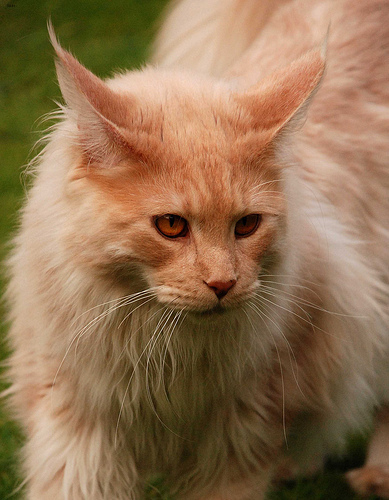

In [ ]:
# We load the dataset using HuggingFace datasets. When you run it in a fresh env it will download the data
dataset = load_dataset("timm/oxford-iiit-pet")
# Dictionaries mapping from index to categories
id2species = {0: "cat", 1: "dog"}
breeds = dataset["train"].features["label"].names
id2breed = {id: label for id, label in enumerate(breeds)}
breed2id = {label: id for id, label in enumerate(breeds)}
# Let's take a look to one of the pics:
example = dataset["train"][0]
print("Species: ", id2species[example["label_cat_dog"]], "\tBreed: ", id2breed[example["label"]])
example["image"]

In [ ]:
# We will use GPU if available. Please make sure to use GPU, unless you're debugging, otherwise it will be painfully slow.
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
# Load model from torchhub (Pytorch repository of models)
model = torch.hub.load('facebookresearch/dino:main', 'dino_vits8')
# Freeze model parameters. We will use the model just as feature extractor, hence we don't update its parameters
for p in model.parameters():
    p.requires_grad = False
model.eval()
model.to(device)

Downloading: "https://github.com/facebookresearch/dino/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dino/dino_deitsmall8_pretrain/dino_deitsmall8_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dino_deitsmall8_pretrain.pth
100%|██████████| 82.7M/82.7M [00:00<00:00, 238MB/s]


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(8, 8), stride=(8, 8))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
  (head): Identity()
)

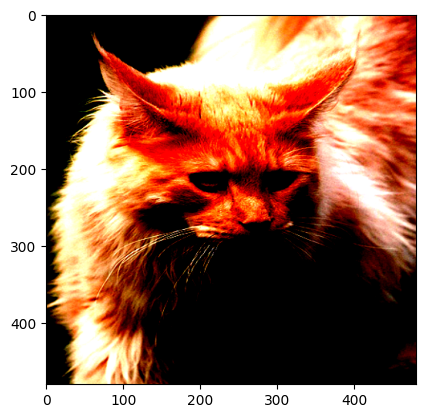

In [ ]:
# We default to image sizes of 480x480
image_size = (480, 480)
# The model that we use uses patches of 8x8
patch_size = 8
# preprocessing
transform = Compose([
    Resize(image_size), # We resize the image to the desired size
    ToTensor(), # convert it to Float tensors in the range [0, 1]
    Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)), # and normalize it to have mean 0 std 1.0
])

# Function to apply the preprocessing
def transforms(examples):
    examples["image"] = [transform(image.convert("RGB")).to(device) for image in examples["image"]]
    return examples
# apply the preprocessing
dataset.set_transform(transforms)
# We take a look to the pre-processed image
example = dataset["train"][0]["image"]
plt.imshow(example.cpu().permute(1, 2, 0))

## Problem 3, Task 1: Plot the attention maps of the CLS  token

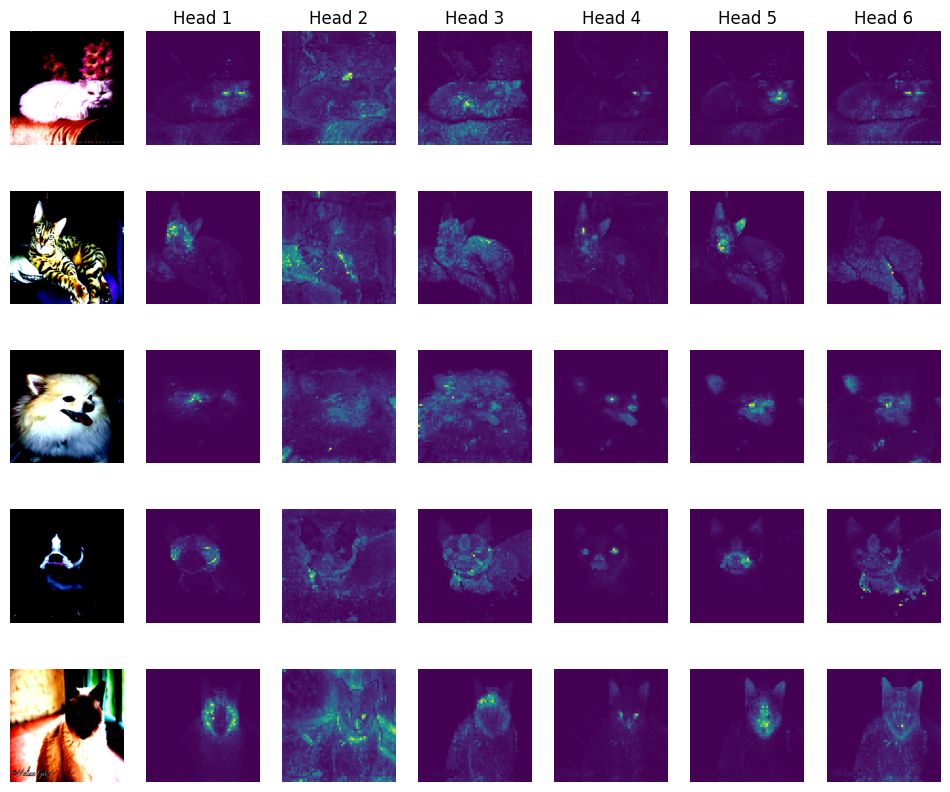

In [ ]:
# We will visualize the attention maps for 5 samples
n_pics = 5
sel_idxs = random.choices(range(len(dataset["train"])), k=n_pics)
# Number of attention heads
num_heads = model.blocks[0].attn.num_heads
# Dimension of image downsampled by patch size
w_featmap = image_size[0] // patch_size
h_featmap = image_size[1] // patch_size
# Create a grid of subplots
fig, axs = plt.subplots(n_pics, num_heads + 1, figsize=(num_heads * 2, n_pics * 2))
# Add titles to the columns
for j, ax in enumerate(axs[0]):
    if j == 0:
        continue
    ax.set_title(f'Head {j}')
for i, sample_idx in enumerate(sel_idxs):
    img = dataset["train"][sample_idx]["image"]
    axs[i, 0].imshow(img.cpu().permute(1, 2, 0))
    axs[i, 0].axis('off')
    # Get attention maps for the current image
    attentions = model.get_last_selfattention(
        img.unsqueeze(0).to(device)
    ) # attention matrix of dimensions: batch size x num heads x (sequence length + 1) x (sequence length + 1) ...
    # ..., the + 1 comes from the special CLS token
    # Extract the attention scores obtained from using the CLS token as query
    attentions = attentions[0, :, 0, 1:]  # Shape: [num_heads, (w_featmap * h_featmap)]
    # Reshape the vector of attention scores (attention map) to the dimension of the downsamples image
    attentions = attentions.reshape(num_heads, w_featmap, h_featmap)
    # Upsample the attention map to the resolution of the original image
    attentions = torch.nn.functional.interpolate(
        attentions.unsqueeze(0),
        scale_factor=patch_size,
        mode="nearest"
    )[0].cpu().numpy()
    # Plot attention maps in the corresponding subplot
    for j, attention_map in enumerate(attentions):
        axs[i, j + 1].imshow(attention_map)
        axs[i, j + 1].axis('off')

plt.show()

**COMMENT**


Some attention heads focus on specific regions, such as eyes (head 4) and body contours (head 3), while others capture global shape and structure (head 2 and head 6).


The model learns to segment objects and regions without explicit supervision as there is no human annotations.

The model identifies meaningful structures and object boundaries purely from self-supervised learning.

## Extracting features

For the following tasks we'll need to convert our dataset of images to a dataset of image embeddings. The following code implements that.

_Note: if you run into out of memory GPU errors, lower the batch size_

In [ ]:
# A dataset that returns also the index of each sample. We use the index to store the embeddings in a big tensor
class ReturnIndexDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset.__getitem__(idx)
        return sample["image"], sample["label"], idx

@torch.no_grad()
def extract_features(model, data_loader):
    features = None
    labels = None
    for samples, targets, index in tqdm(data_loader):
        feats = model(samples).clone()
        # init storage feature matrix
        if features is None:
            features = torch.zeros(len(data_loader.dataset), feats.shape[-1]).cuda(non_blocking=True)
            labels = torch.zeros((len(data_loader.dataset),), dtype=torch.int64).cuda(non_blocking=True)
            print(f"Storing features into tensor of shape {features.shape}")
        # update storage feature matrix
        features.index_copy_(0, index.to(device).view(-1), feats)
        labels.index_copy_(0, index.to(device).view(-1), targets.to(device))
    features = nn.functional.normalize(features, dim=1, p=2)
    return features, labels

batch_size = 4
train_data = ReturnIndexDataset(dataset["train"])
train_loader = DataLoader(train_data, batch_size=batch_size)
test_data = ReturnIndexDataset(dataset["test"])
test_loader = DataLoader(test_data, batch_size=batch_size)

def get_feats_and_labels(split):
    # We check if the features have been already computed and stored in disk, in which case we load them
    if os.path.exists(f"{split}feat.pth"):
        print(f"Loading {split} features and labels from disk ...")
        assert os.path.exists(f"{split}labels.pth"), f"{split} labels not found"
        feats = torch.load(f"{split}feat.pth")
        labels = torch.load(f"{split}labels.pth")
        print(f"{split} features loaded")
    else: # If not, we compute them and save them to disk
        loader = train_loader if split == "train" else test_loader
        print(f"Extracting {split} features ...")
        feats, labels = extract_features(model, loader)
        # save features and labels
        torch.save(feats.cpu(), os.path.join(f"{split}feat.pth"))
        torch.save(labels.cpu(), os.path.join(f"{split}labels.pth"))
    return feats, labels

train_feats, train_labels = get_feats_and_labels("train")
test_feats, test_labels = get_feats_and_labels("test")

Extracting train features ...


  0%|          | 0/920 [00:00<?, ?it/s]

Storing features into tensor of shape torch.Size([3680, 384])
Extracting test features ...


  0%|          | 0/918 [00:00<?, ?it/s]

Storing features into tensor of shape torch.Size([3669, 384])


## Problem 3, Task 2: Visualize the embeddings of the CLS token using t-SNE plots

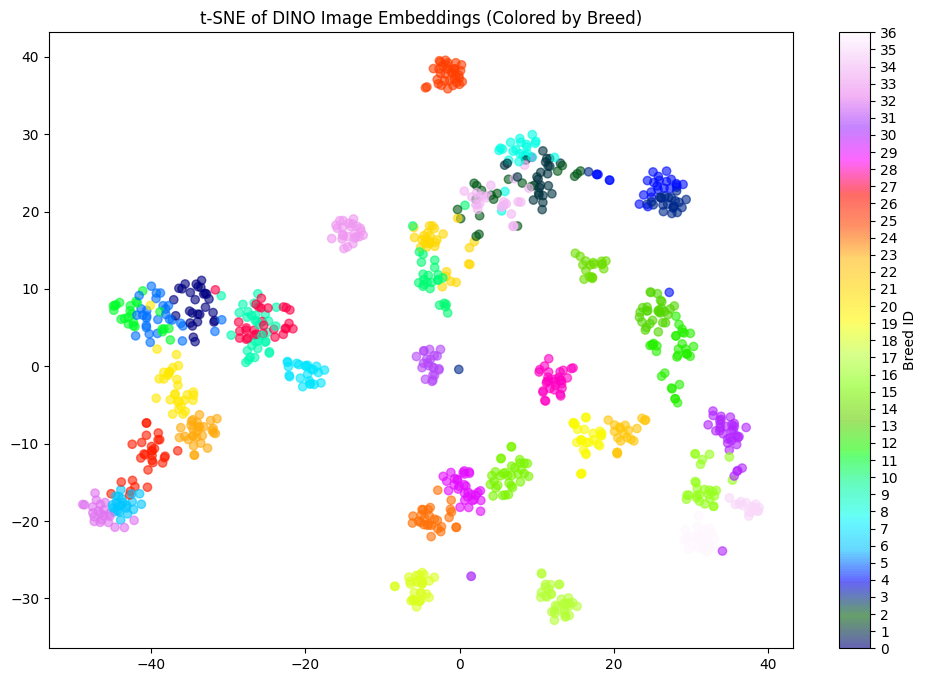

In [ ]:
# TODO: visualize in 2D or 3D the extracted features using a t-SNE plot

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

def plot_tsne(features, labels, n_samples=1000):
    # Randomly sample subset for visualization
    np.random.seed(42)
    rand_idx = np.random.choice(len(features), n_samples, replace=False)
    features_sub = features[rand_idx].cpu().numpy()
    labels_sub = labels[rand_idx].cpu().numpy()

    # Convert numeric labels to breed names
    breed_labels = [id2breed[l] for l in labels_sub]

    # Compute t-SNE
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    embeddings_2d = tsne.fit_transform(features_sub)

    # Plot with breed coloring
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                         c=labels_sub, cmap='gist_ncar', alpha=0.6)
    cbar = plt.colorbar(scatter, ticks=range(37))
    cbar.set_label('Breed ID')
    plt.title("t-SNE of DINO Image Embeddings (Colored by Breed)")
    plt.show()

# Visualize training embeddings
plot_tsne(train_feats, train_labels)

# Optional: Visualize test embeddings
# plot_tsne(test_feats, test_labels)


**COMMENT**

**ANALYSIS**

The t-SNE plot shows distinct clusters, which I interpreted that DINO’s learned embeddings capture meaningful semantic groupings.

Clusters correspond to different dog breeds, showing that the model groups similar-looking images together.

The separation between clusters means that DINO effectively differentiates between breeds based on visual features.

Close clusters may represent visually similar breeds, while distinct clusters likely capture unique features

**What the model is learning**

The model captures high-level visual semantics such as shape, texture, and color without explicit labels.

Even though no breed labels were used during training, the model learns to organize images in a structured way, its representation space is highly informative.


**Supervised vs. Unsupervised Learning**

This is learned in an unsupervised fashion, as the clusters form naturally based on visual similarity, rather than explicit breed labels.

## Problem 3, Task 3: Implement a KNN classifier to classify pet breeds using DINO embeddings

In [ ]:
@torch.no_grad()
def knn_classifier(train_features, train_labels, test_features, test_labels, k, num_classes):
    # TODO: implement the KNN classifier
    # Compute cosine similarities between test and train features
    sim = test_features @ train_features.T  # [num_test, num_train]

    # Find top-k nearest neighbors for each test sample
    _, topk_indices = torch.topk(sim, k, dim=1)  # [num_test, k]

    # Gather labels of nearest neighbors
    neighbor_labels = train_labels[topk_indices]  # [num_test, k]

    # Compute class counts using one-hot encoding
    one_hot = torch.zeros(neighbor_labels.size(0), neighbor_labels.size(1), num_classes,
                        device=neighbor_labels.device)
    one_hot.scatter_(2, neighbor_labels.unsqueeze(-1), 1)
    class_counts = one_hot.sum(dim=1)  # [num_test, num_classes]

    # Calculate top-1 accuracy
    top1_pred = class_counts.argmax(dim=1)
    top1 = (top1_pred == test_labels).float().mean().item()

    # Calculate top-5 accuracy
    _, top5_pred = class_counts.topk(5, dim=1)  # [num_test, 5]
    top5 = (top5_pred == test_labels.view(-1, 1)).any(dim=1).float().mean().item()

    return top1, top5

In [ ]:
nb_knn = [1, 5, 10, 20, 100, 200]
for k in nb_knn:
    top1, top5 = knn_classifier(train_feats, train_labels,
    test_feats, test_labels, k, num_classes=len(id2breed))
    print(f"{k}-NN classifier result: Top1: {top1}, Top5: {top5}")

1-NN classifier result: Top1: 0.8950667381286621, Top5: 0.9201416969299316
5-NN classifier result: Top1: 0.907331645488739, Top5: 0.9833741784095764
10-NN classifier result: Top1: 0.9092395305633545, Top5: 0.9893703460693359
20-NN classifier result: Top1: 0.9114199876785278, Top5: 0.9945489168167114
100-NN classifier result: Top1: 0.8877077698707581, Top5: 0.9986371994018555
200-NN classifier result: Top1: 0.8539111018180847, Top5: 0.9991822838783264


Using cache found in /root/.cache/torch/hub/facebookresearch_dino_main


Extracting train features with random model...


  0%|          | 0/920 [00:00<?, ?it/s]

Storing features into tensor of shape torch.Size([3680, 384])
Extracting test features with random model...


  0%|          | 0/918 [00:00<?, ?it/s]

Storing features into tensor of shape torch.Size([3669, 384])
DINO vs Random Initialization Comparison:
k	DINO Top1	Rand Top1	DINO Top5	Rand Top5
1	0.895		0.049		0.920		0.157
5	0.907		0.048		0.983		0.198
10	0.909		0.050		0.989		0.194
20	0.911		0.053		0.995		0.201
100	0.888		0.050		0.999		0.211
200	0.854		0.049		0.999		0.216


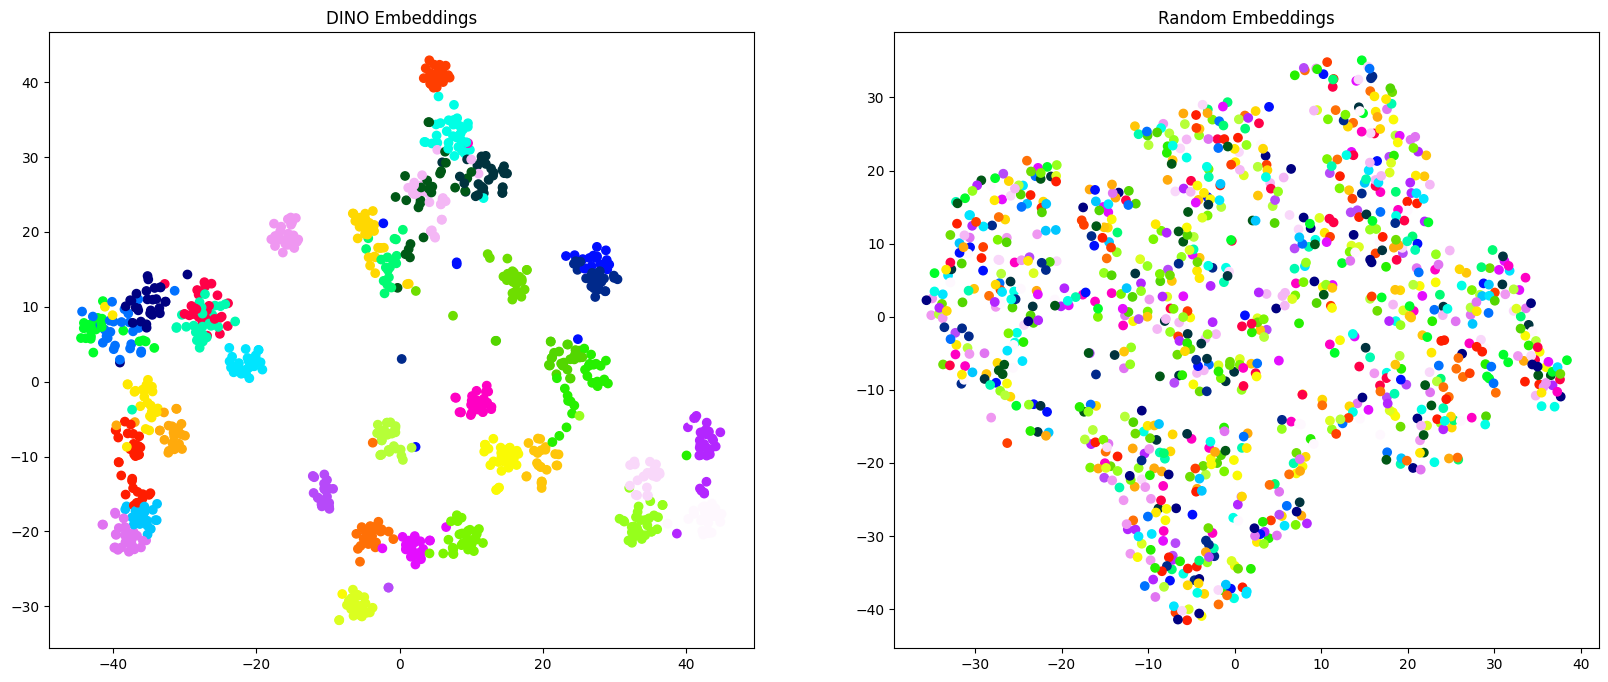

In [ ]:
# TODO: compare the results to using a randomly initialized model to extract embeddings
# model.apply(model._init_weights) # It re-initializes the model, after extract features using the same code as before

# Create a randomly initialized model with same architecture
random_model = torch.hub.load('facebookresearch/dino:main', 'dino_vits8')
random_model.apply(random_model._init_weights)  # Re-initialize weights
random_model.to(device).eval()

# Function to extract features with any model
def get_feats_with_model(model, split):
    feat_path = f"{split}feat_rand.pth"
    label_path = f"{split}labels_rand.pth"

    if os.path.exists(feat_path):
        print(f"Loading {split} random features...")
        return torch.load(feat_path), torch.load(label_path)

    print(f"Extracting {split} features with random model...")
    loader = train_loader if split == "train" else test_loader
    feats, labels = extract_features(model, loader)

    # Save random features with different filenames
    torch.save(feats.cpu(), feat_path)
    torch.save(labels.cpu(), label_path)
    return feats, labels

# Get random model features
rand_train_feats, rand_train_labels = get_feats_with_model(random_model, "train")
rand_test_feats, rand_test_labels = get_feats_with_model(random_model, "test")

# Compare KNN performance
k_values = [1, 5, 10, 20, 100, 200]
num_classes = 37

print("DINO vs Random Initialization Comparison:")
print("k\tDINO Top1\tRand Top1\tDINO Top5\tRand Top5")
for k in k_values:
    # DINO performance
    dino_top1, dino_top5 = knn_classifier(
        train_feats, train_labels,
        test_feats, test_labels, k, num_classes
    )

    # Random model performance
    rand_top1, rand_top5 = knn_classifier(
        rand_train_feats, rand_train_labels,
        rand_test_feats, rand_test_labels, k, num_classes
    )

    print(f"{k}\t{dino_top1:.3f}\t\t{rand_top1:.3f}\t\t{dino_top5:.3f}\t\t{rand_top5:.3f}")

# Visual comparison
def compare_tsne(dino_feats, rand_feats, labels):
    plt.figure(figsize=(20, 8))

    # DINO t-SNE
    plt.subplot(1, 2, 1)
    tsne = TSNE(n_components=2, random_state=42)
    dino_emb = tsne.fit_transform(dino_feats[:1000].cpu().numpy())
    plt.scatter(dino_emb[:,0], dino_emb[:,1], c=labels[:1000].cpu(), cmap='gist_ncar')
    plt.title("DINO Embeddings")

    # Random t-SNE
    plt.subplot(1, 2, 2)
    rand_emb = tsne.fit_transform(rand_feats[:1000].cpu().numpy())
    plt.scatter(rand_emb[:,0], rand_emb[:,1], c=labels[:1000].cpu(), cmap='gist_ncar')
    plt.title("Random Embeddings")

    plt.show()

compare_tsne(train_feats, rand_train_feats, train_labels)

**COMMENT**

**Comparison of DINO vs. Random Embeddings (t-SNE Plots)**

The DINO embeddings (left plot) show clear clusters, indicating that images of the same breed are grouped together while the random embeddings (right plot) appear scattered and unstructured, confirming that without self-supervised learning, the feature space lacks meaningful organization.


**Intuitions from Previous Tasks**

Since DINO clusters semantically similar images, the KNN classifier benefits from a well-structured embedding space.

The strong separation of clusters means that nearest neighbors are likely to belong to the correct class, leading to high classification performance.


**KNN Performance Expectations**

**With embeddings:**
The KNN classifier performs well because it leverages DINO’s feature space, which is already structured based on semantic similarities.

**With raw images:**
A KNN classifier applied directly to pixel values would fail since images in pixel space are not meaningfully structured.
Pixel-wise distances do not capture object-level semantics like DINO embeddings do.

## Problem 3, Task 4: Train a linear classifier to classify pet breeds using DINO embeddings

In [ ]:
# A dataset to serve embeddings and labels
class FeatsDataset(Dataset):
    def __init__(self, feats, labels):
        self.feats = feats
        self.labels = labels

    def __len__(self):
        return len(self.feats)

    def __getitem__(self, idx):
        sample = self.feats[idx]
        label = self.labels[idx]
        return sample, label

In [ ]:
class LinearClassifier(nn.Module):
    def __init__(self, in_size, n_classes):
        # TODO: implement the architecture of the linear classifier
        super().__init__()
        # Single linear layer for classification
        self.linear = nn.Linear(in_size, n_classes)

    def forward(self, x):
        return self.linear(x) # TODO: implement the forward pass

In [ ]:
batch_size = 32
train_data = FeatsDataset(train_feats, train_labels)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_data = FeatsDataset(test_feats, test_labels)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

linear_classifier = LinearClassifier(train_feats.size(1), len(breeds))
linear_classifier.cuda()
optimizer = torch.optim.Adam(linear_classifier.parameters(), lr=0.01)

n_epochs = 10

for epoch in range(n_epochs):
    train_losses = []
    for sample, label in train_loader:
        logits = linear_classifier(sample)
        loss = F.cross_entropy(logits, label)
        # compute the gradients
        optimizer.zero_grad()
        loss.backward()
        # step
        optimizer.step()
        train_losses.append(loss.item())
    test_accs = []
    with torch.no_grad():
        linear_classifier.eval()
        for sample, label in test_loader:
            logits = linear_classifier(sample)
            test_accs.append((1. * (logits.argmax(-1) == label)).mean().item())
        linear_classifier.train()
    train_loss = np.mean(train_losses)
    test_acc = np.mean(test_accs)
    print(f"[epoch {epoch + 1}/{n_epochs}] {train_loss=}, {test_acc=}")

[epoch 1/10] train_loss=1.7530128053996874, test_acc=0.8968555901361548
[epoch 2/10] train_loss=0.5534581205119258, test_acc=0.9247153209603352
[epoch 3/10] train_loss=0.3446390443521997, test_acc=0.9289337474366893
[epoch 4/10] train_loss=0.2592336084531701, test_acc=0.9327380952627763
[epoch 5/10] train_loss=0.21044336686963622, test_acc=0.9355978260869565
[epoch 6/10] train_loss=0.17722185966761217, test_acc=0.9372282608695652
[epoch 7/10] train_loss=0.15306005037349205, test_acc=0.9393892340038134
[epoch 8/10] train_loss=0.1344866533966168, test_acc=0.9406055901361549
[epoch 9/10] train_loss=0.11832629270527674, test_acc=0.940618530045385
[epoch 10/10] train_loss=0.10574255009060321, test_acc=0.9398033126540806


tensor([22, 25,  1, 15, 16, 34, 13, 35, 36, 23,  1, 33,  0,  3, 13, 21,  9, 18,
        12,  2, 33, 21, 12, 19,  9,  6, 26, 13, 17,  9, 30, 30],
       device='cuda:0') Epoch 10: Loss=0.106, Acc=0.969
tensor([12, 28, 16, 31, 32, 21, 24, 21, 19, 23, 32, 31, 33,  7, 30,  5, 15,  6,
        10, 30, 20, 32,  0, 18, 32, 17,  9, 12,  3,  7, 22,  0],
       device='cuda:0') Epoch 10: Loss=0.106, Acc=0.969
tensor([ 7, 30, 28, 29, 34, 32,  3, 36, 13, 16, 22,  6, 11, 23, 18, 35, 31,  0,
        27, 11,  8,  7, 15, 23,  3, 14, 24,  6, 12,  7, 21, 12],
       device='cuda:0') Epoch 10: Loss=0.106, Acc=0.958
tensor([26, 23, 28, 23, 30, 28, 28,  8, 17, 10, 19, 23, 27, 18,  8, 11,  7, 22,
         9,  4, 17, 13,  3, 15, 30,  9, 11, 19, 16,  9,  3, 11],
       device='cuda:0') Epoch 10: Loss=0.106, Acc=0.945
tensor([16, 23, 34, 27, 27, 31, 15, 35, 23, 21, 17,  0,  1, 11, 24, 33, 10,  8,
        22, 12, 11, 22, 35, 33, 27, 29,  7, 10, 11, 19, 18, 26],
       device='cuda:0') Epoch 10: Loss=0.106, Acc=0

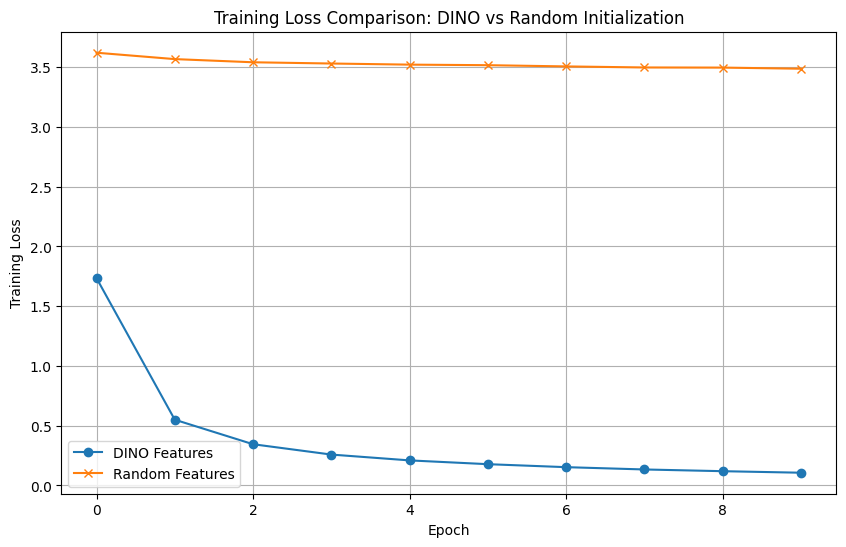

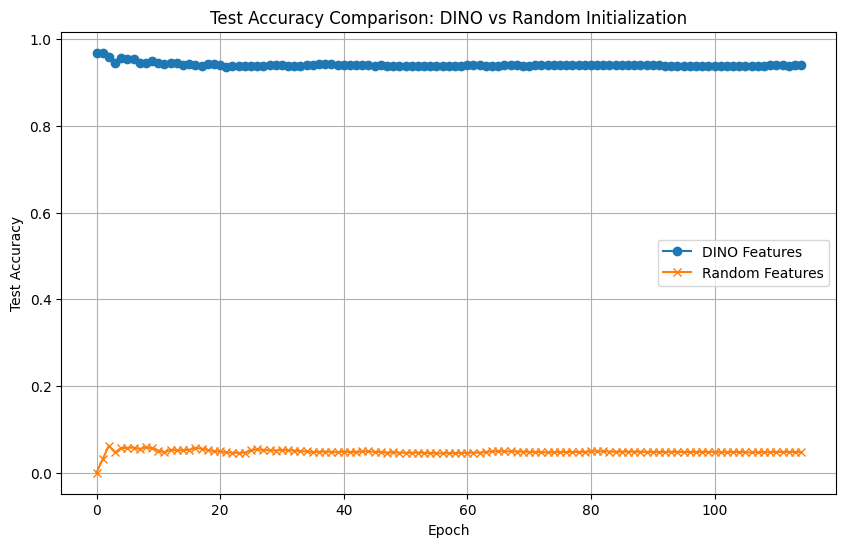

In [ ]:
# TODO: compare the results to using a randomly initialized model to extract embeddings
# model.apply(model._init_weights) # It re-initializes the model, after extract features using the same code as before

import matplotlib.pyplot as plt

def train_linear(feats_train, labels_train, feats_test, labels_test, label):
    train_data = FeatsDataset(feats_train, labels_train)
    test_data = FeatsDataset(feats_test, labels_test)

    model = LinearClassifier(feats_train.size(1), len(breeds)).cuda()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    train_losses = []
    test_accuracies = []

    for epoch in range(n_epochs):
        model.train()
        epoch_losses = []
        for sample, label in DataLoader(train_data, batch_size=32, shuffle=True):
            logits = model(sample.cuda())
            loss = F.cross_entropy(logits, label.cuda())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())

        # Store average epoch loss
        train_losses.append(np.mean(epoch_losses))

        # Evaluation
        model.eval()
        accs = []
    for sample, label in DataLoader(test_data, batch_size=32):
        sample = sample.cuda()        # Move input to GPU.
        label = label.cuda()          # Move label to GPU.
        logits = model(sample)        # Compute logits on GPU.
        # Compare predictions and labels on GPU, then move the result to CPU.
        acc = (logits.argmax(-1) == label).float().mean().cpu()
        accs.append(acc.item())

        test_accuracies.append(np.mean(accs))
        print(f"{label} Epoch {epoch+1}: Loss={train_losses[-1]:.3f}, Acc={test_accuracies[-1]:.3f}")

    return train_losses, test_accuracies

# Run training for both models
dino_train_loss, dino_test_acc = train_linear(
    train_feats, train_labels, test_feats, test_labels, "DINO"
)

rand_train_loss, rand_test_acc = train_linear(
    rand_train_feats, rand_train_labels,
    rand_test_feats, rand_test_labels, "Random"
)

# Plot loss comparison
plt.figure(figsize=(10, 6))
plt.plot(dino_train_loss, label='DINO Features', marker='o')
plt.plot(rand_train_loss, label='Random Features', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Comparison: DINO vs Random Initialization')
plt.legend()
plt.grid(True)
plt.show()

# Plot accuracy comparison
plt.figure(figsize=(10, 6))
plt.plot(dino_test_acc, label='DINO Features', marker='o')
plt.plot(rand_test_acc, label='Random Features', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy Comparison: DINO vs Random Initialization')
plt.legend()
plt.grid(True)
plt.show()

**COMMENT**

DINO embeddings capture high-level semantic structures, making it easier for a linear classifier to separate different categories.



A linear classifier on DINO embeddings will perform well (as seen in above plot) because DINO embeddings are structured in a way that similar images (belonging to the same class) have closer representations.

On the other hand, if we apply a linear classifier directly to raw images, it will perform poorly (as confirmed from plot above) because raw pixels don’t inherently contain meaningful separability for different classes.


## Problem 3, Task 5: Train a linear classifier to segment food in the FoodSeg103 dataset using DINO's CLS attention maps

README.md:   0%|          | 0.00/6.71k [00:00<?, ?B/s]

train-00000-of-00003.parquet:   0%|          | 0.00/351M [00:00<?, ?B/s]

train-00001-of-00003.parquet:   0%|          | 0.00/357M [00:00<?, ?B/s]

train-00002-of-00003.parquet:   0%|          | 0.00/431M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/115M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4983 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2135 [00:00<?, ? examples/s]

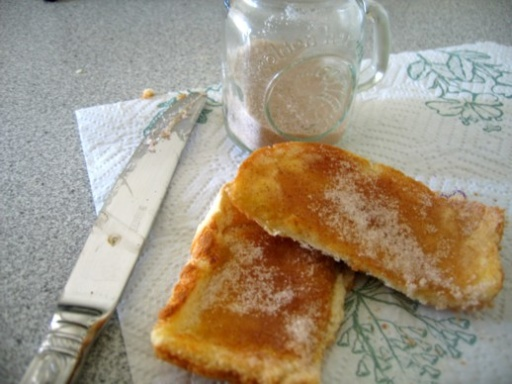

In [ ]:
# We load the dataset using HuggingFace datasets. When you run it in a fresh env it will download the data
dataset = load_dataset("EduardoPacheco/FoodSeg103")
# Let's take a look to one of the pics:
example = dataset["train"][2]
example["image"]

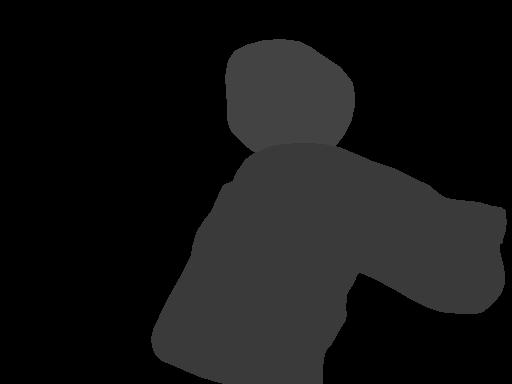

In [ ]:
segmentation_map = example["label"]
segmentation_map

In the segmentation map, every pixel is labeled with a certain class. 0 is the "background" class:

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
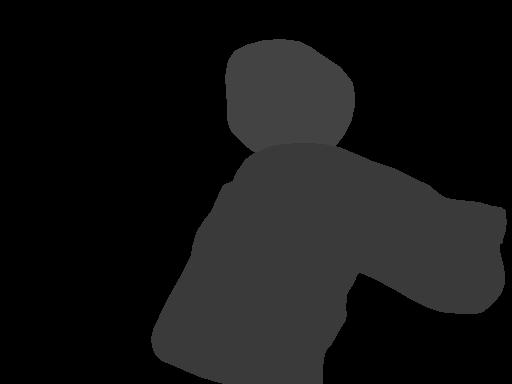

In [ ]:
np.array(segmentation_map)

Here is a dictionary with the remaining classes:

In [ ]:
id2label = {
    0: "background",
    1: "candy",
    2: "egg tart",
    3: "french fries",
    4: "chocolate",
    5: "biscuit",
    6: "popcorn",
    7: "pudding",
    8: "ice cream",
    9: "cheese butter",
    10: "cake",
    11: "wine",
    12: "milkshake",
    13: "coffee",
    14: "juice",
    15: "milk",
    16: "tea",
    17: "almond",
    18: "red beans",
    19: "cashew",
    20: "dried cranberries",
    21: "soy",
    22: "walnut",
    23: "peanut",
    24: "egg",
    25: "apple",
    26: "date",
    27: "apricot",
    28: "avocado",
    29: "banana",
    30: "strawberry",
    31: "cherry",
    32: "blueberry",
    33: "raspberry",
    34: "mango",
    35: "olives",
    36: "peach",
    37: "lemon",
    38: "pear",
    39: "fig",
    40: "pineapple",
    41: "grape",
    42: "kiwi",
    43: "melon",
    44: "orange",
    45: "watermelon",
    46: "steak",
    47: "pork",
    48: "chicken duck",
    49: "sausage",
    50: "fried meat",
    51: "lamb",
    52: "sauce",
    53: "crab",
    54: "fish",
    55: "shellfish",
    56: "shrimp",
    57: "soup",
    58: "bread",
    59: "corn",
    60: "hamburg",
    61: "pizza",
    62: "hanamaki baozi",
    63: "wonton dumplings",
    64: "pasta",
    65: "noodles",
    66: "rice",
    67: "pie",
    68: "tofu",
    69: "eggplant",
    70: "potato",
    71: "garlic",
    72: "cauliflower",
    73: "tomato",
    74: "kelp",
    75: "seaweed",
    76: "spring onion",
    77: "rape",
    78: "ginger",
    79: "okra",
    80: "lettuce",
    81: "pumpkin",
    82: "cucumber",
    83: "white radish",
    84: "carrot",
    85: "asparagus",
    86: "bamboo shoots",
    87: "broccoli",
    88: "celery stick",
    89: "cilantro mint",
    90: "snow peas",
    91: "cabbage",
    92: "bean sprouts",
    93: "onion",
    94: "pepper",
    95: "green beans",
    96: "French beans",
    97: "king oyster mushroom",
    98: "shiitake",
    99: "enoki mushroom",
    100: "oyster mushroom",
    101: "white button mushroom",
    102: "salad",
    103: "other ingredients"
}

In [ ]:
# TODO: implement the segmentation model using the attention maps of the CLS token


import torch.nn as nn
import numpy as np
import torch
from torch.utils.data import Dataset
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
from PIL import Image

class DINOSegmentation(nn.Module):
    def __init__(self, dino_model, num_classes):
        super().__init__()
        self.dino = dino_model
        self.conv = nn.Conv2d(
            self.dino.embed_dim,  # DINO feature dimension
            num_classes,          # Number of segmentation classes
            kernel_size=1
        )

    def forward(self, x):
        # Get DINO features and attention
        with torch.no_grad():
            features = self.dino.get_intermediate_layers(x, n=1)[0]
            attn = self.dino.get_last_selfattention(x)

        # Use CLS token attention as segmentation weights
        cls_attn = attn[:, :, 0, 1:]  # [batch, heads, h*w]
        cls_attn = cls_attn.mean(dim=1)  # Average over heads
        h = w = int(cls_attn.shape[-1]**0.5)
        cls_attn = cls_attn.reshape(-1, h, w)  # [batch, h, w]

        # Resize features to match attention map
        features = features[:, 1:]  # Remove CLS token
        features = features.permute(0, 2, 1)  # [batch, dim, h*w]
        features = features.reshape(-1, features.shape[1], h, w)

        # Combine features with attention
        weighted_features = features * cls_attn.unsqueeze(1)

        # Final classification
        logits = self.conv(weighted_features)  # [batch, num_classes, h, w]

        # Resize logits to match the label size (480x480)
        logits_resized = F.interpolate(logits, size=(480, 480), mode="bilinear", align_corners=False)

        return logits_resized  # Now shape [batch, num_classes, 480, 480]

# Initialize model
num_classes = len(id2label)
seg_model = DINOSegmentation(model, num_classes).to(device)

# Training setup
criterion = nn.CrossEntropyLoss(ignore_index=0)  # Ignore background
optimizer = torch.optim.Adam(seg_model.parameters(), lr=0.001)

# Dataset preparation

class SegmentationDataset(Dataset):
    def __init__(self, dataset, image_transform, label_size=(480, 480)):
        self.dataset = dataset
        self.image_transform = image_transform
        self.label_size = label_size

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        # Process the image using the provided transform.
        image = self.image_transform(item["image"].convert("RGB"))

        # Process the label:
        # Convert the label (assumed to be a NumPy array) to a PIL Image.
        label_array = np.array(item["label"])
        label_pil = Image.fromarray(label_array.astype('uint8'))
        # Resize using nearest neighbor to avoid interpolation artifacts.
        label_resized = label_pil.resize(self.label_size, resample=Image.NEAREST)
        # Convert back to a tensor.
        label = torch.from_numpy(np.array(label_resized)).long()

        return image, label

# Data transforms for images.
from torchvision.transforms import Resize, ToTensor, Compose, Normalize
image_transform = Compose([
    Resize((480, 480)),
    ToTensor(),
    Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

# Create datasets
train_data = SegmentationDataset(dataset["train"], image_transform)
train_loader = DataLoader(train_data, batch_size=8, shuffle=True)
val_data = SegmentationDataset(dataset["validation"], image_transform)
val_loader = DataLoader(val_data, batch_size=8)

# Training loop
for epoch in range(10):
    seg_model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = seg_model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Validation
    seg_model.eval()
    with torch.no_grad():
        val_loss = 0
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = seg_model(images)
            val_loss += criterion(outputs, labels).item()

    print(f"Epoch {epoch+1}: Train Loss={loss.item():.3f}, Val Loss={val_loss/len(val_loader):.3f}")

Epoch 1: Train Loss=4.332, Val Loss=4.291


In [ ]:
def visualize_segmentation(image, pred):
    plt.figure(figsize=(12, 6))

    # Original image
    plt.subplot(1, 2, 1)
    plt.imshow(image.cpu().permute(1, 2, 0))
    plt.title("Input")

    # Segmentation
    plt.subplot(1, 2, 2)
    plt.imshow(pred.argmax(dim=0).cpu(), cmap='nipy_spectral')
    plt.title("Segmentation")
    plt.show()

# Example visualization
image, label = val_data[0]
with torch.no_grad():
    pred = seg_model(image.unsqueeze(0).to(device))[0]
visualize_segmentation(image, pred)